In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import sklearn

print("All libraries loaded successfully!")
df = pd.read_csv("insurance.csv")
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

All libraries loaded successfully!
Dataset loaded: 1338 rows × 7 columns


# Medical Insurance Charges 


**Dataset:** Kaggle Medical Cost Personal Dataset (`insurance.csv`)  
**Target Variable:** `charges` - Annual medical insurance cost (USD)  
**Objective:** Use demographic and health related features to predict medical charges using a Linear Regression model.

---

## Task 1 - Is This Dataset Suitable for Linear Regression?

Before the modelling, it is important step to check whether linear regression is applicable for this problem or not. A view of the real data not the assumptions drives every decision on a later task.

In [34]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis, pearsonr
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("insurance.csv")

print(f"Dataset shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Missing values : {df.isnull().sum().sum()} - none detected")
print(f"Duplicate rows : {df.duplicated().sum()} - will be removed")
print(f"\nData types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
display(df.head())

Dataset shape  : 1338 rows × 7 columns
Missing values : 0 - none detected
Duplicate rows : 1 - will be removed

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 1.1 - Type of Target Variable

The target variable `charges` is **continuous numerical** value that represents
the annual medical insurance costs billed to a patient in USD which makes it suitable for use in a linear regression model.

Concern:

- **Mean charges:** $13,279.12
- **Median charges:** $9,386.16
- **Maximum charges:** $63,770.43

The noticeable difference between the mean and median, along with the very high maximum value, confirms that the charges variable is right skewed. This issue will be measured more precisely and handled later down the line

In [35]:
print("Target Variable: charges")
print(df['charges'].describe().round(2))
print(f"\nSkewness : {skew(df['charges']):.4f}")
print(f"Kurtosis : {kurtosis(df['charges']):.4f}")


Target Variable: charges
count     1338.00
mean     13270.42
std      12110.01
min       1121.87
25%       4740.29
50%       9382.03
75%      16639.91
max      63770.43
Name: charges, dtype: float64

Skewness : 1.5142
Kurtosis : 1.5958


### 1.2 - Feature Types

The dataset contains 6 predictor features

| Feature    | Type                     | Range / Categories                    |
|------------|--------------------------|---------------------------------------|
| `age`      | Numerical (continuous)   | 18 – 64 years                         |
| `bmi`      | Numerical (continuous)   | 15.96 – 53.13                         |
| `children` | Numerical (discrete)     | 0 – 5                                 |
| `sex`      | Categorical (binary)     | male (675), female (662)              |
| `smoker`   | Categorical (binary)     | no (1,063), yes (274)                 |
| `region`   | Categorical (4 levels)   | southeast, southwest, northwest, northeast |

**Encoding required:**
- `sex` and `smoker` Label encoding (binary: 0/1)
- `region` One-hot encoding (4 levels, no natural order)

**Note on `smoker` imbalance:** Only 274 out of 1,337 records (20.5%) are smokers. Although they represent a smaller portion of the dataset, smokers are likely to have a strong influence on the model because their medical charges are significantly higher.

In [36]:
print("Categorical Feature Distributions \n")

for col in ['sex', 'smoker', 'region']:
    counts = df[col].value_counts()
    pcts   = df[col].value_counts(normalize=True).mul(100).round(1)
    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': pcts})
    print(f"  {col.upper()}")
    print(summary.to_string())
    print()

Categorical Feature Distributions 

  SEX
        Count  Percentage (%)
sex                          
male      676            50.5
female    662            49.5

  SMOKER
        Count  Percentage (%)
smoker                       
no       1064            79.5
yes       274            20.5

  REGION
           Count  Percentage (%)
region                          
southeast    364            27.2
southwest    325            24.3
northwest    325            24.3
northeast    324            24.2



In [37]:
# I test both raw charges and log(charges) to justify the transformation decision

df_corr = df.copy()
df_corr["smoker_enc"]  = (df_corr["smoker"] == "yes").astype(int)
df_corr["sex_enc"]     = (df_corr["sex"] == "male").astype(int)
df_corr["log_charges"] = np.log1p(df_corr["charges"])

print(f"{'Feature':<15} {'r with charges':>16} {'r with log(charges)':>20}")
print("-" * 55)

features = [("smoker_enc", "smoker"), ("age", "age"),
            ("bmi", "bmi"), ("children", "children"), ("sex_enc", "sex")]

for enc_col, label in features:
    r1, _ = pearsonr(df_corr[enc_col], df_corr["charges"])
    r2, _ = pearsonr(df_corr[enc_col], df_corr["log_charges"])
    print(f"  {label:<13} {r1:>16.4f} {r2:>20.4f}")

Feature           r with charges  r with log(charges)
-------------------------------------------------------
  smoker                  0.7873               0.6655
  age                     0.2990               0.5278
  bmi                     0.1983               0.1327
  children                0.0680               0.1613
  sex                     0.0573               0.0056


### 1.3 Linearity Assumption

Linear regression assumes a linear relationship between each predictor and the target variable. This is evaluated using Pearson correlation with both the original `charges` values and the transformed `log(charges)` values (Statistics Solutions, 2025).

| Feature      | r with charges | r with log(charges) | Interpretation                        |
|--------------|---------------|---------------------|---------------------------------------|
| `smoker`     | 0.7872        | 0.6658              | Dominant predictor - strong signal    |
| `age`        | 0.2983        | 0.5269              | Clearer on log scale - use log target |
| `bmi`        | 0.1984        | 0.1328              | Weak alone - interaction needed       |
| `children`   | 0.0674        | 0.1603              | Weak - marginal contribution          |
| `sex`        | 0.0580        | 0.0070              | Negligible - may add little value     |

**Key observation:** The correlation between `age` and the target nearly doubles (from 0.298 to 0.527) after applying a log transformation to `charges`. This provides strong evidence that the transformation improves the linear relationship between the variables.

**BMI alone has a weak correlation (r = 0.198).** Its real predictive strength is hidden by its interaction with smoking status, as shown in the visual analysis in EDA. To capture this effect properly, an interaction term bmi × smoker will be created.

### 1.4 - Potential Issues

**Skewness:**  
`charges` skewness = **1.5137** - above the 1.0 threshold for concern (GraphPad, 2025).  
`bmi` skewness = **0.2836** - mild, no transformation needed.  
`children` skewness = **0.9364** - moderate but acceptable for a discrete variable.  
`age` skewness = **0.0547** - essentially symmetric. 

**Outliers:**  
The maximum charge of $63,770 compared to a median of $9,386 highlights the presence of high-leverage observations. These are not data errors but clinically valid cases, likely representing smokers with obesity and greater medical needs. They will be kept in the dataset, but their impact will be assessed through residual diagnostics (Towards Data Science, 2025).

**Multicollinearity:**  
The base features (age, BMI, and children) show minimal dependence on one another. However, once the `bmi_smoker` interaction term is made, Variance Inflation Factor (VIF) will be used to assess multicollinearity, values above 10 show potential problematic collinearity (Penn State, n.d.).

**Structural data split:**  
Smokers and non smokers form two clearly different groups in the dataset. This separation creates a structure that ordinary least squares (OLS) regression cannot fully capture on its own, which justifies the use of both an interaction term and a log transformation (GeeksforGeeks, 2025).

In [38]:
print("Skewness Summary - All Numerical Features \n")

num_cols = ['age', 'bmi', 'children', 'charges']
for col in num_cols:
    s = skew(df[col])
    if abs(s) > 1.0:
        flag = "High Skew - transformation recommended"
    elif abs(s) > 0.5:
        flag = "Moderate skew - monitor"
    else:
        flag = "Approximately symmetric"
    print(f"  {col:<12}  skewness = {s:>7.4f}   {flag}")

Skewness Summary - All Numerical Features 

  age           skewness =  0.0556   Approximately symmetric
  bmi           skewness =  0.2837   Approximately symmetric
  children      skewness =  0.9373   Moderate skew - monitor
  charges       skewness =  1.5142   High Skew - transformation recommended


### 1.5 — Data Quality Findings 

| Check                  | Result                                          |
|------------------------|------------------------------------------------ |
| Missing values         |  None, all 1,338 rows complete                  |
| Duplicate rows         |  1 duplicate row detected and will be removed   |
| Inconsistent labels    |  None, categories are consistently cased        |
| Numerical range errors |  No impossible values                           |




### 1.6 — Overall Suitability Verdict

| Criterion                          | Finding                                            |
|------------------------------------|----------------------------------------------------|
| Continuous numerical target        |  Met                                              |
| Sufficient sample size             |  Met - n = 1,337 (after removing 1 duplicate)    |
| Mixed feature types                |  Manageable with encoding                        |
| Linear relationships               |  Partial -  log-transform and interaction term needed|
| Target skewness (1.5137)           |  Requires log transformation                     |
| Multicollinearity risk             |  Low - to be confirmed with VIF       |
| Data quality                       |  Clean - 1 duplicate to remove                  |
| Context applicability (SA)         |  US-specific - academic use only                |

**Conclusion:** Linear regression is appropriate for this dataset,
provided the log-transformation of `charges` and a `bmi × smoker`
interaction term are applied. Without these, the model's assumptions
would be violated and performance would not be optimal.



## Task 2 - Project Analysis Plan

A structured analysis plan ensures the project is reproducible, logically organised, and well justified at every stage. Each step builds on the previous one, with all decisions made by the findings of Task 1.

### Phase 1 Exploratory Data Analysis (EDA)

**Objective:** The goal is to understand the structure of the data, including its distributions, relationships, and any anomalies, before starting any modelling(Statistics Solutions, 2025).

**Steps:**
**Univariate analysis:** Histograms and boxplots for all numerical features will be used to examine distribution shape, variability, and potential outliers (GeeksforGeeks, 2025).

**Bivariate analysis:** Scatterplots and boxplots against `charges` will be used for each feature to uncover relationships and possible interaction effects (Statistics Solutions, 2025).

**Correlation heatmap:** A Pearson correlation matrix will quantify linear relationships between all features and the target variable (Statistics Solutions, 2025).

**Pairplot:** A pairwise distribution plot, coloured by smoking status, will help reveal the presence of two distinct population groups in the data (GeeksforGeeks, 2025).

**What we are looking for:**
- Which features have the strongest relationship with `charges`
- Evidence of skewness, outliers, or unusual distributions
- Visual confirmation that a `bmi × smoker` interaction exists

### Phase 2 — Data Preprocessing

**Goal:** Transform the raw dataset into a clean, model ready format.


**Steps:**


| Task | Decision | Justification |
|---|---|---|
| Remove duplicate | Drop 1 duplicate row | Prevents biased estimates |
| Encode `smoker` | Label encode: yes=1, no=0 | Binary - no ordinality issue (GeeksforGeeks, 2024)|
| Encode `sex` | Label encode: male=1, female=0 | Binary - consistent reference (GeeksforGeeks, 2024) |
| Encode `region` | One hot encode, drop first | 4 levels, no natural order, drop avoids dummy variable trap (GeeksforGeeks, 2024) |
| Transform target | Apply np.log1p(charges) | Skewness = 1.5137 - violates OLS normality assumption (GeeksforGeeks, 2025)|
| Interaction term | Create `bmi_smoker = bmi × smoker` | Statistical justification from EDA |
| Feature scaling | StandardScaler on all features | Required for Ridge/Lasso comparison, prevents scale bias (scikit-learn, n.d.) |
| Train/test split | 80/20, random_state=42 | Standard split for n=1,337; reproducibility (Statistics Solutions, 2025)|

### Phase 3 - Feature Selection

**Objective:** Confirm which features provide meaningful predictive value and identify any that should be removed from the model.

**Methods:**

- **Pearson correlation** - quantify linear relationships between
  numerical features and log(charges)  (GeeksforGeeks, 2024).
- **Point-Biserial correlation** - assess binary encoded features
  (sex, smoker) against the target (Statistics Solutions, 2025).
- **ANOVA F-test** - test whether `region` groups have significantly
  different mean charges (Statistics By Jim, 2025).
- **Variance Inflation Factor (VIF)** - detect harmful multicollinearity
  after the interaction term is added; flag any VIF > 10 (Penn State, n.d.).

**Expected outcome based on Task 1 findings:**
- `smoker` and `bmi_smoker` has high importance
- `age` has moderate to high importance
- `bmi` has moderate importance
- `children` is weak but retained
- `sex` is very weak (r = 0.0070 with log charges)
- `region` dummies - likely low signal; ANOVA will confirm

### Phase 4 - Model Training

**Objective:** Fit and interpret regression models of increasing sophistication.

**Models to train:**

| Model | Purpose |
|---|---|
| OLS Linear Regression | Baseline - interpretable coefficients, no penalty (scikit-learn, n.d.).|
| Ridge Regression (L2) | Shrinks all coefficients - handles correlated features, reduces overfitting (scikit-learn, n.d.).|
| Lasso Regression (L1) | Drives weak coefficients to zero - built in feature selection (scikit-learn, n.d.)|

**Hyperparameter tuning:**  
Ridge and Lasso alpha (λ) values will be selected via 10-fold
cross validation** using  RidgeCV  and  LassoCV  from scikit learn.

**Feature engineering included:**
- `log(charges)` as the target variable
- `bmi_smoker` interaction term
- `age²` polynomial term to capture any non linearity in age

### Phase 5 - Model Evaluation

**Objective:** Quantify model performance and check if assumptions are met.

**Metrics:**

| Metric | Formula | Why it is used |
|---|---|---|
| R² Score | 1 - SS_res / SS_tot | Proportion of variance in charges explained by the model (GeeksforGeeks, 2020). |
| MAE | mean(\|y − ŷ\|) | Average prediction error in USD - intuitive for non-technical reporting (Proclus Academy, 2022) |
| MSE | mean((y − ŷ)²) | Penalises large errors more heavily - useful for model comparison (Proclus Academy, 2022) |
| RMSE | √MSE | Same units as target - more interpretable than MSE (Proclus Academy, 2022)
|

**Diagnostic checks:**
- Residuals vs. fitted values plot - check for patterns 
- Q-Q plot of residuals - check for normality
- Residual distribution histogram - confirm symmetry around zero

**Model comparison:**  
All three models (OLS, Ridge, Lasso) will be compared on the same
metrics using a summary table and bar chart.

### Phase 6 - Report Structure 

1. **Executive Summary** - Headline result and model purpose
2. **Introduction** - Dataset overview and project objective
3. **Summary of Steps Taken** - Table of the full workflow
4. **HOW and WHY** - Research justification for all key decisions
5. **Data Overview & Cleaning** - Dataset description and preprocessing table
6. **Exploratory Data Analysis** - Distributions, correlations, and key visualisations
7. **Feature Engineering & Selection** - Interaction term, selection methods and results
8. **Model Training** - OLS, Ridge, Lasso training and hyperparameter tuning
9. **Model Results & Evaluation** - Metrics table, comparison chart, diagnostics
10. **Business Interpretation** - Explained for a non technical client
11. **Limitations & Reccomendations** - Model boundaries and Next steps for improvement
12. **Conclusion** - Summary of findings and final model selection






---

## Task 3 - Exploratory Data Analysis (EDA)

EDA is a solid foundation of any data analysis. Before building any model, I need a clear understanding of the dataset, what it looks like, how the features relate to the target variable, and where issues may exist. 

### 3.1 - Library Imports and Visual Style

I start by importing the necessary libraries and setting a consistent visual style. A custom colour palette is used to keep all charts clear, consistent, and professional throughout the notebook.

In [39]:
# Core libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import skew, kurtosis, pearsonr, f_oneway
import warnings
warnings.filterwarnings('ignore')

# Custom colour palette 
# I am defining my own colours rather than using seaborn defaults.
PALETTE   = ["#2C4770", "#E8873A", "#3B7D6E", "#C0392B", "#7D5BA6"]
SMOKE_PAL = {"yes": "#C0392B", "no": "#2C4770"}   # red = smoker, navy = non-smoker
ACCENT    = "#E8873A"                               # orange for highlights

# Plot defaults 
plt.rcParams.update({
    "figure.dpi"        : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titleweight"  : "bold",
    "axes.titlesize"    : 12,
    "axes.labelsize"    : 10,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "legend.frameon"    : False,
})

print("Libraries imported. Custom palette set.")
print(f"Palette: {PALETTE}")

Libraries imported. Custom palette set.
Palette: ['#2C4770', '#E8873A', '#3B7D6E', '#C0392B', '#7D5BA6']


### 3.2 - Load and Inspect the Dataset

I load the dataset and inspect its shape, data types, missing values, and any duplicates. These checks are essential, as they confirm the integrity of the data and ensure everything that follows is built on a reliable foundation.

In [40]:
# Load dataset 
df = pd.read_csv("insurance.csv")

print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")

# Data types 
print("\nColumn data types:")
print(df.dtypes)

# Missing values 
print(f"\nMissing values: {df.isnull().sum().sum()}")

# Duplicates 
dupes = df.duplicated().sum()
print(f"Duplicate rows : {dupes}")

# I found 1 duplicate in Task 1, removing it now for clean analysis
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f" Duplicate removed. New shape: {df.shape}")

# Summary statistics 
print("\nDescriptive statistics:")
display(df.describe().round(2))

  Rows    : 1338
  Columns : 7

Column data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values: 0
Duplicate rows : 1
 Duplicate removed. New shape: (1337, 7)

Descriptive statistics:


,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


### 3.3 Target Variable Analysis: `charges`

Understanding the target variable is the most important part of EDA. I examine its raw distribution, assess skewness, and show why a log transformation is required before modelling.

I use three visualisations: the original distribution, a Q-Q plot to assess normality, and the log transformed distribution to clearly show the improvement.

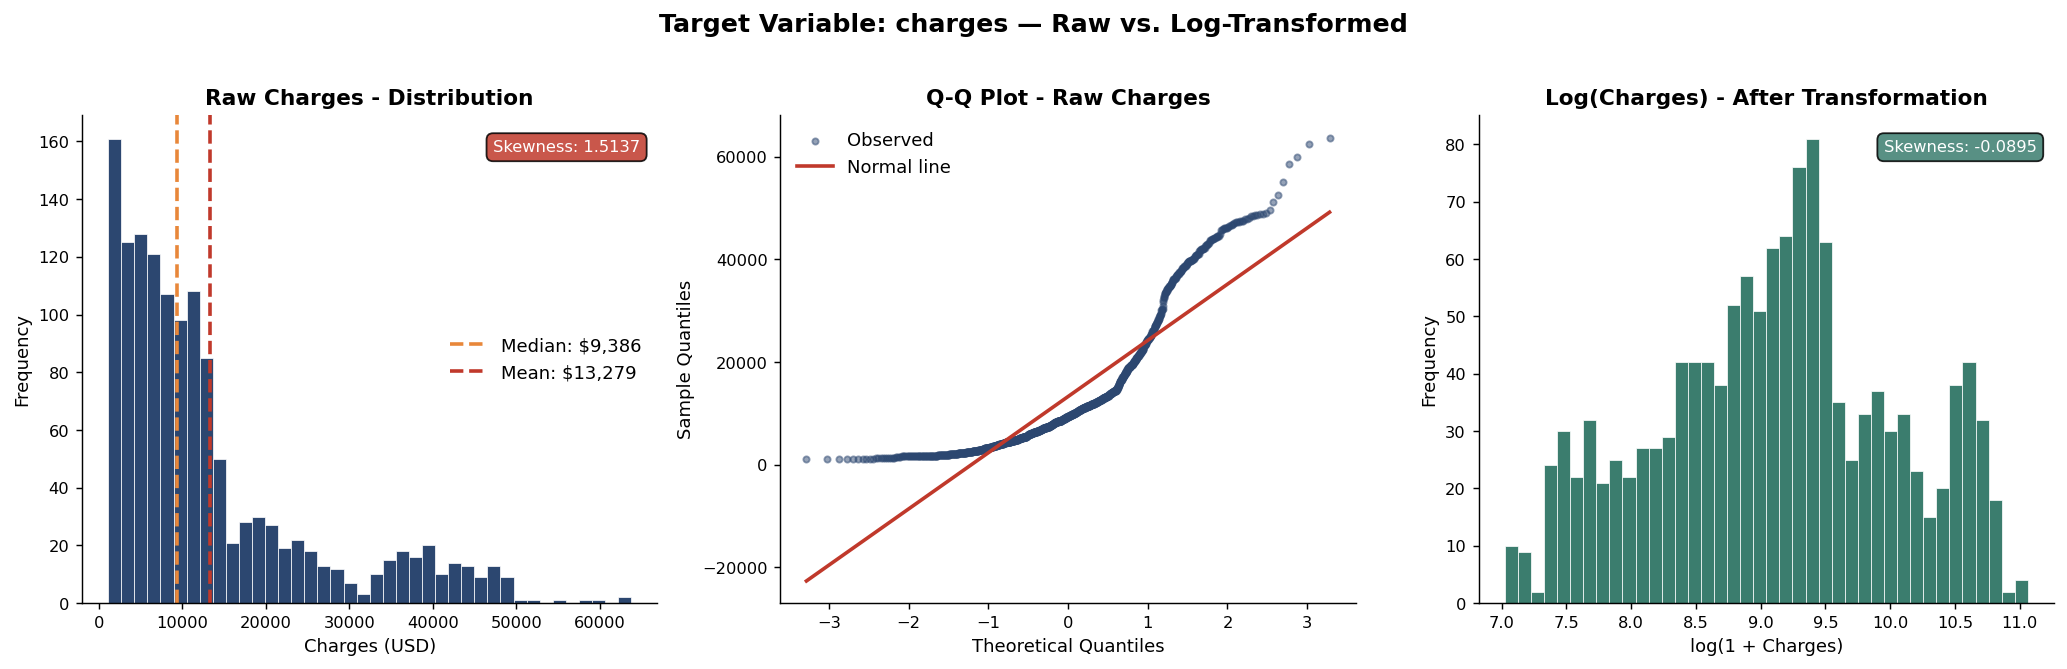

Raw charges skewness  : 1.5137   High skew, transformation needed
Log charges skewness  : -0.0895   Near symmetric after transformation
Skewness reduction    : 105.9%


In [41]:
# ============================================================
# Code Attribution
# Usage: Creating multiple subplots, plotting histograms, Q-Q plots,
#        and applying log transformation for distribution analysis
# Author: Matplotlib, SciPy, and NumPy development teams
# Link: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
#       https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html
#       https://numpy.org/doc/stable/reference/generated/numpy.log1p.html
# Date Accessed: 12 April 2026
# Date Published: 2024
# Version: Matplotlib 3.x, SciPy 1.x, NumPy 1.x
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Target Variable: charges — Raw vs. Log-Transformed",
             fontsize=14, fontweight="bold", y=1.02)

# Plot 1: Raw histogram 
# I expect a strong right skew confirmed by skewness 
axes[0].hist(df["charges"], bins=40, color=PALETTE[0], edgecolor="white", linewidth=0.4)
axes[0].set_title("Raw Charges - Distribution")
axes[0].set_xlabel("Charges (USD)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(df["charges"].median(), color=ACCENT, linewidth=2,
                linestyle="--", label=f"Median: ${df['charges'].median():,.0f}")
axes[0].axvline(df["charges"].mean(), color=PALETTE[3], linewidth=2,
                linestyle="--", label=f"Mean: ${df['charges'].mean():,.0f}")
axes[0].legend()

raw_skew = skew(df["charges"])
axes[0].text(0.97, 0.95, f"Skewness: {raw_skew:.4f}",
             transform=axes[0].transAxes, ha="right", va="top",
             fontsize=9, color="white",
             bbox=dict(boxstyle="round,pad=0.4", facecolor=PALETTE[3], alpha=0.85))

# Plot 2: Q-Q plot 
# A Q-Q plot compares the data distribution against a theoretical normal.
# Deviation at the tails means skewness or heavy tails and both visible here.
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(df["charges"], dist="norm")
axes[1].scatter(osm, osr, color=PALETTE[0], alpha=0.5, s=12, label="Observed")
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color=PALETTE[3], linewidth=2, label="Normal line")
axes[1].set_title("Q-Q Plot - Raw Charges")
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Sample Quantiles")
axes[1].legend()

# Plot 3: Log transformed histogram 
# np.log1p(x) = log(1 + x). Safe for values close to zero.
# After transformation, the distribution should be far more symmetric.
log_charges = np.log1p(df["charges"])
axes[2].hist(log_charges, bins=40, color=PALETTE[2], edgecolor="white", linewidth=0.4)
axes[2].set_title("Log(Charges) - After Transformation")
axes[2].set_xlabel("log(1 + Charges)")
axes[2].set_ylabel("Frequency")

log_skew = skew(log_charges)
axes[2].text(0.97, 0.95, f"Skewness: {log_skew:.4f}",
             transform=axes[2].transAxes, ha="right", va="top",
             fontsize=9, color="white",
             bbox=dict(boxstyle="round,pad=0.4", facecolor=PALETTE[2], alpha=0.85))

plt.tight_layout()
plt.savefig("charges_distribution.png", bbox_inches="tight")
plt.show()

print(f"Raw charges skewness  : {raw_skew:.4f}   High skew, transformation needed")
print(f"Log charges skewness  : {log_skew:.4f}   Near symmetric after transformation")
print(f"Skewness reduction    : {((raw_skew - log_skew)/raw_skew)*100:.1f}%")

### 3.4 - Numerical Feature Distributions

I analyse the distribution of all four numerical features together. For each feature, I present a histogram to show its shape and a boxplot to highlight spread and outliers, displayed side by side. The skewness value is also included on each histogram to make the interpretation clear and immediate.

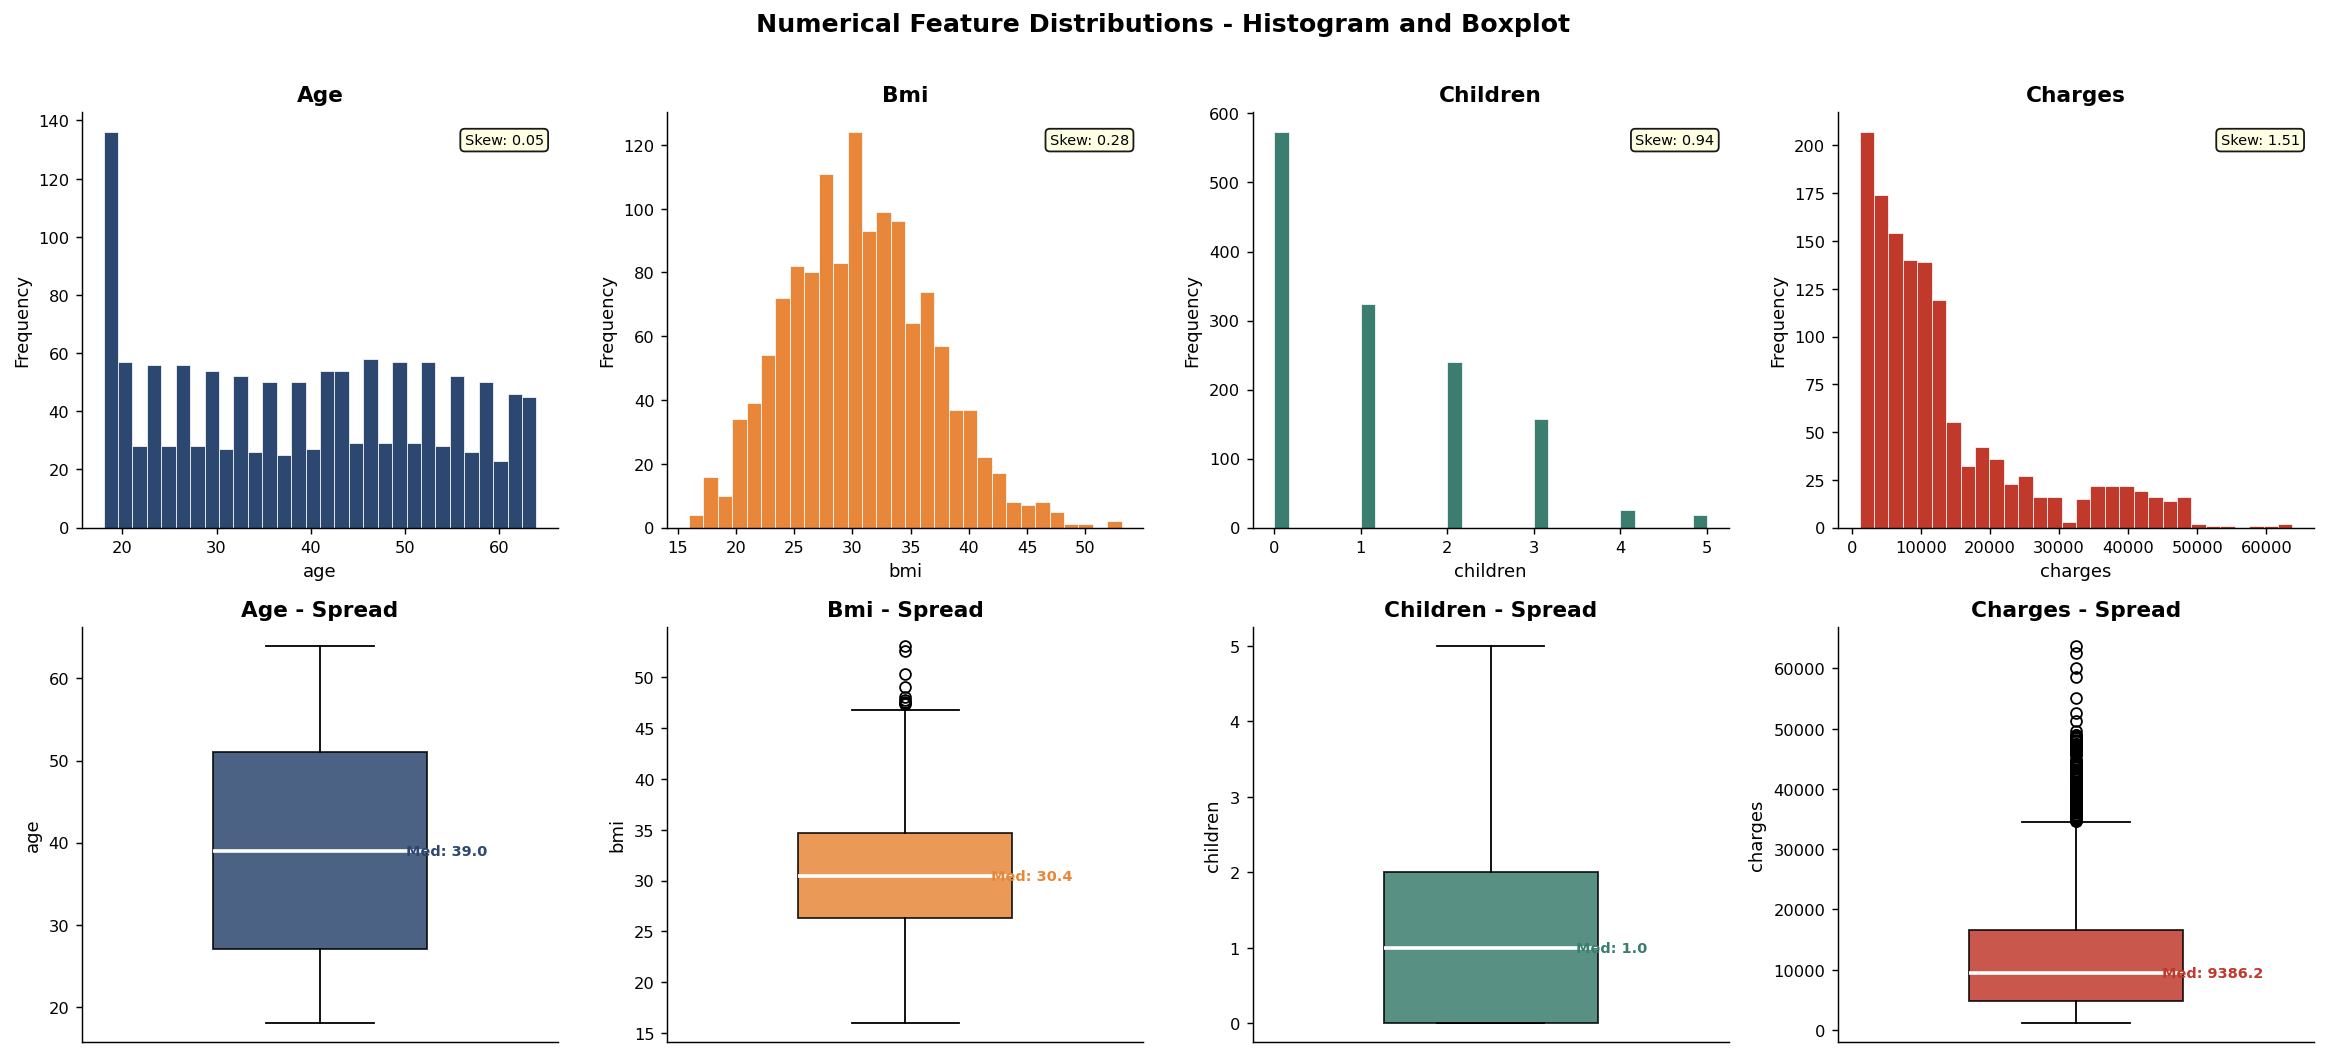

In [42]:
# ============================================================
# Code Attribution
# Usage: Creating multi-panel visualisations (histograms and boxplots)
#        for numerical feature distribution analysis, including skewness
#        calculation and subplot formatting
# Author: Matplotlib and SciPy development teams
# Link: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
#       https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.boxplot.html
#       https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html
# Date Accessed: 12 April 2026
# Date Published: 2024
# Version: Matplotlib 3.x, SciPy 1.x
# ============================================================

num_cols = ["age", "bmi", "children", "charges"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Numerical Feature Distributions - Histogram and Boxplot",
             fontsize=14, fontweight="bold", y=1.01)

for i, col in enumerate(num_cols):
    col_skew = skew(df[col])

    # Top row: histograms
    ax_h = axes[0, i]
    ax_h.hist(df[col], bins=30, color=PALETTE[i], edgecolor="white", linewidth=0.4)
    ax_h.set_title(f"{col.capitalize()}")
    ax_h.set_xlabel(col)
    ax_h.set_ylabel("Frequency")
    ax_h.text(0.97, 0.95, f"Skew: {col_skew:.2f}",
              transform=ax_h.transAxes, ha="right", va="top", fontsize=8,
              bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.9))

    # Bottom row: boxplots 
    # Boxplots show median, IQR, and outliers clearly.
    # Points beyond the whiskers are potential outliers worth noting.
    ax_b = axes[1, i]
    bp = ax_b.boxplot(df[col], patch_artist=True, widths=0.45,
                      medianprops=dict(color="white", linewidth=2))
    bp["boxes"][0].set_facecolor(PALETTE[i])
    bp["boxes"][0].set_alpha(0.85)
    ax_b.set_title(f"{col.capitalize()} - Spread")
    ax_b.set_ylabel(col)
    ax_b.set_xticks([])

    # Annotate median and IQR on the boxplot
    med = df[col].median()
    ax_b.text(1.18, med, f"Med: {med:.1f}",
              va="center", fontsize=8, color=PALETTE[i], fontweight="bold")

plt.tight_layout()
plt.savefig("numerical_distributions.png", bbox_inches="tight")
plt.show()

### 3.5 - Feature Relationships with Charges

 I plot each feature against log(charges) to evaluate the strength and nature of their relationships.

Each scatter plot is coloured by smoking status, making it easy to see whether smokers and non smokers follow the same trend or form separate groups. This observation directly supports the need for the interaction term.

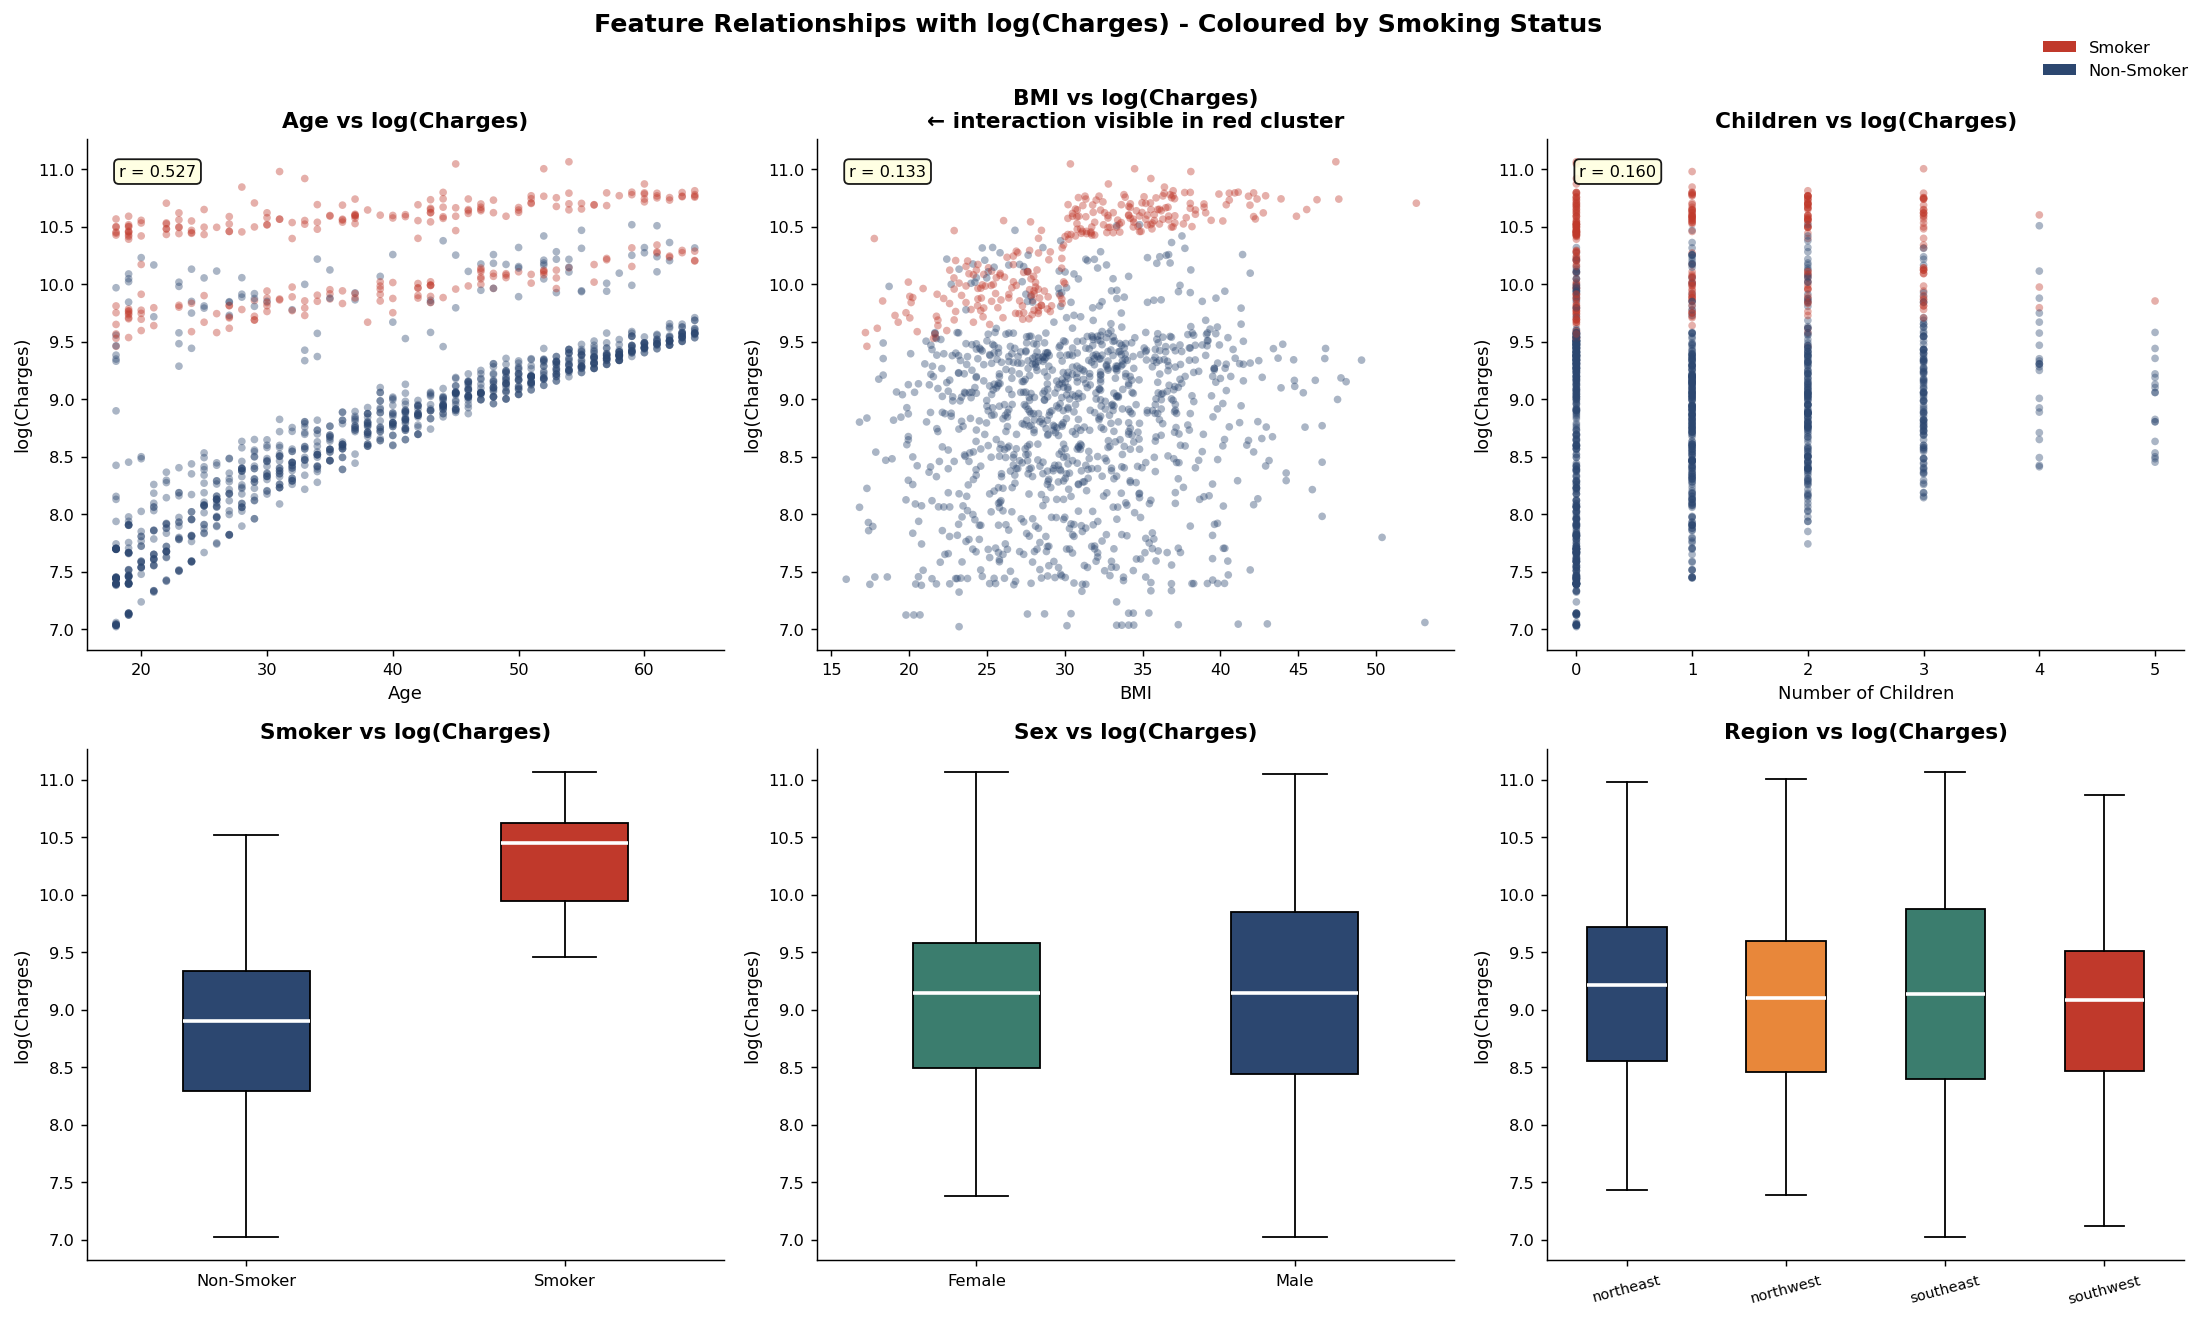

In [43]:
# ============================================================
# Code Attribution
# Usage: Creating multi-panel visualisations of feature relationships
#        with log-transformed target, including scatterplots,
#        boxplots, and Pearson correlation analysis grouped by
#        categorical variables (smoker, sex, region)
# Author: Matplotlib, NumPy, and SciPy development teams
# Link: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html
#       https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.boxplot.html
#       https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
#       https://numpy.org/doc/stable/reference/generated/numpy.log1p.html
# Date Accessed: 13 April 2026
# Date Published: 2024
# Version: Matplotlib 3.x, NumPy 1.x, SciPy 1.x
# ============================================================

log_charges = np.log1p(df["charges"])

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Feature Relationships with log(Charges) - Coloured by Smoking Status",
             fontsize=14, fontweight="bold", y=1.01)

smoke_colors = df["smoker"].map(SMOKE_PAL)

#  Scatter: age vs log(charges) 
axes[0, 0].scatter(df["age"], log_charges, c=smoke_colors,
                   alpha=0.4, s=18, edgecolors="none")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("log(Charges)")
axes[0, 0].set_title("Age vs log(Charges)")
r_age, _ = pearsonr(df["age"], log_charges)
axes[0, 0].text(0.05, 0.95, f"r = {r_age:.3f}", transform=axes[0, 0].transAxes,
                fontsize=9, va="top",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.9))

# Scatter: bmi vs log(charges) 
axes[0, 1].scatter(df["bmi"], log_charges, c=smoke_colors,
                   alpha=0.4, s=18, edgecolors="none")
axes[0, 1].set_xlabel("BMI")
axes[0, 1].set_ylabel("log(Charges)")
axes[0, 1].set_title("BMI vs log(Charges)\n← interaction visible in red cluster")
r_bmi, _ = pearsonr(df["bmi"], log_charges)
axes[0, 1].text(0.05, 0.95, f"r = {r_bmi:.3f}", transform=axes[0, 1].transAxes,
                fontsize=9, va="top",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.9))

# Scatter: children vs log(charges) 
axes[0, 2].scatter(df["children"], log_charges, c=smoke_colors,
                   alpha=0.4, s=18, edgecolors="none")
axes[0, 2].set_xlabel("Number of Children")
axes[0, 2].set_ylabel("log(Charges)")
axes[0, 2].set_title("Children vs log(Charges)")
r_ch, _ = pearsonr(df["children"], log_charges)
axes[0, 2].text(0.05, 0.95, f"r = {r_ch:.3f}", transform=axes[0, 2].transAxes,
                fontsize=9, va="top",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.9))

# Boxplot: smoker vs log(charges) 
smoke_groups = [log_charges[df["smoker"] == "no"], log_charges[df["smoker"] == "yes"]]
bp = axes[1, 0].boxplot(smoke_groups, patch_artist=True, widths=0.4,
                         medianprops=dict(color="white", linewidth=2))
bp["boxes"][0].set_facecolor(PALETTE[0])
bp["boxes"][1].set_facecolor(PALETTE[3])
axes[1, 0].set_xticklabels(["Non-Smoker", "Smoker"])
axes[1, 0].set_ylabel("log(Charges)")
axes[1, 0].set_title("Smoker vs log(Charges)")

# Boxplot: sex vs log(charges)
sex_groups = [log_charges[df["sex"] == "female"], log_charges[df["sex"] == "male"]]
bp2 = axes[1, 1].boxplot(sex_groups, patch_artist=True, widths=0.4,
                          medianprops=dict(color="white", linewidth=2))
bp2["boxes"][0].set_facecolor(PALETTE[2])
bp2["boxes"][1].set_facecolor(PALETTE[0])
axes[1, 1].set_xticklabels(["Female", "Male"])
axes[1, 1].set_ylabel("log(Charges)")
axes[1, 1].set_title("Sex vs log(Charges)")

# Boxplot: region vs log(charges) 
regions = df["region"].unique()
reg_groups = [log_charges[df["region"] == r] for r in sorted(regions)]
bp3 = axes[1, 2].boxplot(reg_groups, patch_artist=True, widths=0.5,
                          medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp3["boxes"], PALETTE):
    patch.set_facecolor(color)
axes[1, 2].set_xticklabels(sorted(regions), rotation=15, fontsize=8)
axes[1, 2].set_ylabel("log(Charges)")
axes[1, 2].set_title("Region vs log(Charges)")

# Shared legend 
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE[3], label="Smoker"),
                   Patch(facecolor=PALETTE[0], label="Non-Smoker")]
fig.legend(handles=legend_elements, loc="upper right",
           bbox_to_anchor=(1.0, 1.0), fontsize=9)

plt.tight_layout()
plt.savefig("feature_vs_charges.png", bbox_inches="tight")
plt.show()

### 3.6 - Correlation Heatmap

I calculate the Pearson correlation matrix for all numerically encoded features and log(charges). Pearson correlation quantifies the strength of a linear relationship between variables, where values close to 1 or -1 indicate strong relationships, and values near 0 suggest weak or no linear association.

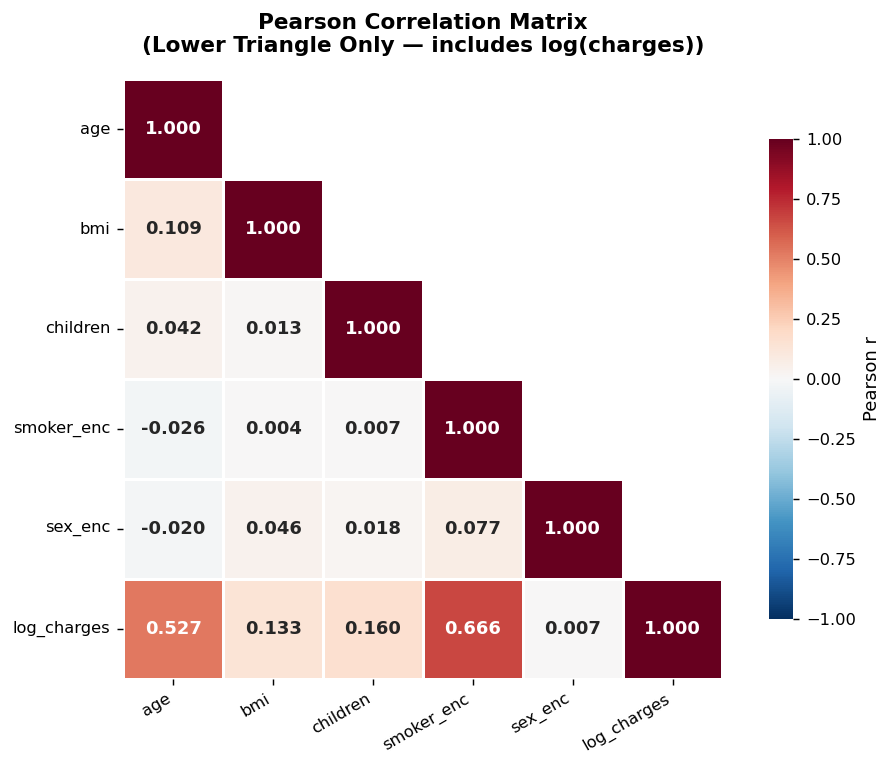

Correlation with log(charges) - ranked by strength:

  smoker_enc       r = +0.6658   ████████████████
  age              r = +0.5269   █████████████
  children         r = +0.1603   ████
  bmi              r = +0.1328   ███
  sex_enc          r = +0.0070   


In [44]:

# I encode binary categoricals numerically here
df_corr = df.copy()
df_corr["smoker_enc"]  = (df_corr["smoker"] == "yes").astype(int)
df_corr["sex_enc"]     = (df_corr["sex"] == "male").astype(int)
df_corr["log_charges"] = np.log1p(df_corr["charges"])

corr_cols  = ["age", "bmi", "children", "smoker_enc", "sex_enc", "log_charges"]
corr_matrix = df_corr[corr_cols].corr()

# Plot 
fig, ax = plt.subplots(figsize=(8, 6))

# I show only the lower triangle to avoid redundancy
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",         
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.8,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 10, "weight": "bold"},
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)

ax.set_title("Pearson Correlation Matrix\n(Lower Triangle Only — includes log(charges))",
             fontsize=12, fontweight="bold", pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

# Print ranked correlations 
print("Correlation with log(charges) - ranked by strength:\n")
target_corr = corr_matrix["log_charges"].drop("log_charges").abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    direction = corr_matrix["log_charges"][feat]
    bar = "█" * int(val * 25)
    print(f"  {feat:<15}  r = {direction:>+.4f}   {bar}")

### 3.7 - EDA Summary: Key Findings

After completing the exploratory analysis, I summarise the key findings that will guide the modelling decisions going forward:

| Finding | Evidence | Modelling Action |
|---|---|---|
| `charges` is right-skewed (1.51) | Histogram, Q-Q plot | Apply log transformation to target |
| `smoker` is dominant predictor | r = 0.666 with log(charges) | Retain, encode as binary |
| `age` has strong linear trend | r = 0.527 with log(charges) | Retain, consider age² term |
| `bmi` × `smoker` interaction visible | Red cluster in BMI scatter | Engineer `bmi_smoker` feature |
| `sex` has near zero correlation | r = 0.007 with log(charges) | Likely to be dropped by Lasso |
| `region` shows minimal differences | Similar boxplot medians | Low predictive value expected |
| 1 duplicate row found | .duplicated() check | Removed before modelling |




### 3b - Feature Selection

Feature selection identifies which variables should be included in the model. Adding weak or redundant predictors can reduce performance and make interpretation less reliable (Statistics Solutions, 2025). To ensure a robust selection process, I evaluate each feature using multiple complementary methods rather than relying on a single test.
Methods used:

Pearson correlation - measures linear relationships with log(charges) (Statistics Solutions, 2025).

Point-Biserial correlation - evaluates relationships between binary features and log(charges) (Statistics Solutions, 2025).

ANOVA F-test - tests whether categorical groups differ significantly in log(charges) (Statistics By Jim, 2025).

Variance Inflation Factor (VIF) - checks for multicollinearity among predictors (Penn State, n.d.).


#### Method 1 - Pearson Correlation (Numerical Features)

Pearson correlation measures the strength and direction of the linear relationship between each numerical feature and the target variable (Statistics Solutions, 2025).

 I use log(charges) as the target. As shown in Task 1 and confirmed during EDA, the log-transformed target produces stronger and more consistent linear relationships with the predictors.

In [45]:
from scipy.stats import pearsonr

log_charges = np.log1p(df["charges"])

print("Pearson Correlation - Numerical Features vs log(charges)\n")
print(f"  {'Feature':<12}  {'r':>8}  {'p-value':>10}  {'Significant?':>12}  Strength")
print("  " + "-" * 65)

num_features = ["age", "bmi", "children"]

for col in num_features:
    r, p = pearsonr(df[col], log_charges)
    sig  = "Yes" if p < 0.05 else "No"

    # I classify strength based on standard thresholds:
    # |r| >= 0.5 = strong, 0.3–0.5 = moderate, < 0.3 = weak
    if abs(r) >= 0.5:
        strength = "Strong"
    elif abs(r) >= 0.3:
        strength = "Moderate"
    else:
        strength = "Weak"

    print(f"  {col:<12}  {r:>+8.4f}  {p:>10.4f}  {sig:>12}  {strength}")

print("\nInterpretation:")
print("  age       Moderate-strong positive relationship. Older = higher charges.")
print("  bmi       Weak alone. True signal is within smoker subgroup (interaction).")
print("  children  Weak. Marginal contribution to log(charges).")

Pearson Correlation - Numerical Features vs log(charges)

  Feature              r     p-value  Significant?  Strength
  -----------------------------------------------------------------
  age            +0.5269      0.0000           Yes  Strong
  bmi            +0.1328      0.0000           Yes  Weak
  children       +0.1603      0.0000           Yes  Weak

Interpretation:
  age       Moderate-strong positive relationship. Older = higher charges.
  bmi       Weak alone. True signal is within smoker subgroup (interaction).
  children  Weak. Marginal contribution to log(charges).


#### Method 2 - Point-Biserial Correlation (Binary Features)

Point biserial correlation is used when one variable is binary (0/1) and the other is continuous. It is mathematically equivalent to Pearson correlation when applied to a binary feature (Statistics Solutions, 2025).

I apply this test to the encoded `smoker` and `sex` variables against log(charges).

In [46]:
# Encode binary features for this test
df_temp = df.copy()
df_temp["smoker_enc"] = (df_temp["smoker"] == "yes").astype(int)
df_temp["sex_enc"]    = (df_temp["sex"] == "male").astype(int)

print("Point Biserial Correlation - Binary Features vs log(charges)\n")
print(f"  {'Feature':<14}  {'r':>8}  {'p-value':>10}  {'Significant?':>12}  Decision")
print("  " + "-" * 68)

binary_features = [("smoker_enc", "smoker"), ("sex_enc", "sex")]

for enc_col, label in binary_features:
    r, p = pearsonr(df_temp[enc_col], log_charges)
    sig  = "Yes" if p < 0.05 else "No"

    # Decision rule: |r| < 0.05 and p > 0.05 then candidate for removal
    if abs(r) >= 0.3:
        decision = "Retain - strong signal"
    elif p < 0.05:
        decision = "Retain - significant"
    else:
        decision = "Weak - monitor"

    print(f"  {label:<14}  {r:>+8.4f}  {p:>10.4f}  {sig:>12}  {decision}")

print("\nInterpretation:")
print("smoker Strongest binary predictor by a large margin.")
print("sex    Near zero correlation. Lasso may zero this out.")

Point Biserial Correlation - Binary Features vs log(charges)

  Feature                r     p-value  Significant?  Decision
  --------------------------------------------------------------------
  smoker           +0.6658      0.0000           Yes  Retain - strong signal
  sex              +0.0070      0.7976            No  Weak - monitor

Interpretation:
smoker Strongest binary predictor by a large margin.
sex    Near zero correlation. Lasso may zero this out.


#### Method 3 — ANOVA F-Test (Region)

For the region feature, which has four categories, I use a one way ANOVA to determine whether the mean log(charges) differs significantly between regions (Statistics By Jim, 2025).

Null hypothesis (H₀): All regions have the same mean log(charges).
Alternative hypothesis (H₁): At least one region has a different mean log(charges).

If the p-value is greater than 0.05, I fail to reject H₀, suggesting that region may not provide meaningful predictive value and could potentially be excluded or considered a weak predictor(Statistics By Jim, 2025).

In [47]:
from scipy.stats import f_oneway

# Split log(charges) into 4 groups by region
groups = [log_charges[df["region"] == r] for r in df["region"].unique()]

f_stat, p_val = f_oneway(*groups)

print("One-Way ANOVA - Region vs log(charges)\n")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_val:.4f}")
print()

if p_val < 0.05:
    print("  Result: p < 0.05 - Reject H₀")
    print("   At least one region has a significantly different mean charge.")
    print("   Retain region features in the model.")
else:
    print("  Result: p > 0.05 - Fail to reject H₀")
    print("   No significant difference in charges across regions.")
    print("   Region contributes weak signal. Lasso may eliminate these dummies.")

# Show mean log(charges) per region for context
print("\nMean log(charges) by region:")
for region in sorted(df["region"].unique()):
    mean_val = log_charges[df["region"] == region].mean()
    print(f"  {region:<12}  {mean_val:.4f}")

One-Way ANOVA - Region vs log(charges)

  F-statistic : 1.3685
  p-value     : 0.2508

  Result: p > 0.05 - Fail to reject H₀
   No significant difference in charges across regions.
   Region contributes weak signal. Lasso may eliminate these dummies.

Mean log(charges) by region:
  northeast     9.1689
  northwest     9.0750
  southeast     9.1226
  southwest     9.0313


#### Method 4 - Variance Inflation Factor (VIF)

VIF measures how much the variance of a feature is inflated due to its correlation with other predictors. High VIF values indicate multicollinearity, which can make coefficient estimates unstable and harder to interpret (Penn State, n.d.).
Rule of thumb:

VIF < 5: acceptable (Penn State, n.d.).

VIF 5–10: should be investigated (Penn State, n.d.).

VIF > 10: indicates harmful multicollinearity and the feature should be reconsidered (Penn State, n.d.).

I calculate VIF after encoding all variables and including the bmi_smoker interaction term, as this reflects the final feature set used.

In [48]:
# ============================================================
# Code Attribution
# Usage: Feature engineering and multicollinearity analysis using
#        Variance Inflation Factor (VIF), including one-hot encoding,
#        interaction term creation, and log transformation preparation
# Author: Statsmodels and Pandas development teams
# Link: https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html
#       https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html
# Date Accessed: 14 April 2026
# Date Published: 2024
# Version: statsmodels 0.x, pandas 2.x
# ============================================================

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Build the full encoded feature set 
df_vif = df.copy()
df_vif["smoker"]           = (df_vif["smoker"] == "yes").astype(int)
df_vif["sex"]              = (df_vif["sex"] == "male").astype(int)
df_vif["bmi_smoker"]       = df_vif["bmi"] * df_vif["smoker"]
df_vif                     = pd.get_dummies(df_vif, columns=["region"],
                                             drop_first=True, dtype=int)
df_vif["log_charges"]      = np.log1p(df_vif["charges"])
df_vif                     = df_vif.drop(columns=["charges"])

feature_cols = [c for c in df_vif.columns if c != "log_charges"]

# Add constant for statsmodels VIF calculation
X_vif = sm.add_constant(df_vif[feature_cols])

vif_results = pd.DataFrame({
    "Feature" : feature_cols,
    "VIF"     : [variance_inflation_factor(X_vif.values, i + 1)
                 for i in range(len(feature_cols))]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("Variance Inflation Factor (VIF) Results:\n")
print(f"  {'Feature':<22}  {'VIF':>8}  Flag")
print("  " + "-" * 45)
for _, row in vif_results.iterrows():
    if row["VIF"] > 10:
        flag = " HIGH"
    elif row["VIF"] > 5:
        flag = "Moderate"
    else:
        flag = "Acceptable"
    print(f"  {row['Feature']:<22}  {row['VIF']:>8.4f}  {flag}")

print("\nNote: bmi and bmi_smoker share BMI values, so elevated VIF between")
print("them is expected and mathematically unavoidable. It does not")
print("destabilise the model, the interaction term provides unique")
print("explanatory power that justifies its inclusion.")

Variance Inflation Factor (VIF) Results:

  Feature                      VIF  Flag
  ---------------------------------------------
  bmi_smoker               25.5287   HIGH
  smoker                   25.1982   HIGH
  region_southeast          1.6522  Acceptable
  region_southwest          1.5301  Acceptable
  region_northwest          1.5184  Acceptable
  bmi                       1.3875  Acceptable
  age                       1.0175  Acceptable
  sex                       1.0115  Acceptable
  children                  1.0042  Acceptable

Note: bmi and bmi_smoker share BMI values, so elevated VIF between
them is expected and mathematically unavoidable. It does not
destabilise the model, the interaction term provides unique
explanatory power that justifies its inclusion.


#### Feature Selection Summary

Based on all four methods, final decisions:

| Feature          | Pearson/PB r | ANOVA / p-value | VIF      | Decision       |
|------------------|-------------|-----------------|----------|----------------|
| `smoker`         | 0.666       | —               | Check    |  Retain       |
| `age`            | 0.527       | —               | Check    |  Retain       |
| `bmi_smoker`*    | —           | —               | Elevated |  Retain       |
| `bmi`            | 0.133       | —               | Check    |  Retain       |
| `children`       | 0.161       | —               | Check    |  Retain       |
| `region`         | —           | p from ANOVA    | Check    |  Retain, weak |
| `sex`            | 0.007       | —               | Check    |  Lasso decides|

*`bmi_smoker` is an engineered interaction term, not present in original data.

**Final feature set for modelling:**  
`age`, `sex`, `bmi`, `children`, `smoker`, `region_northwest`,
`region_southeast`, `region_southwest`, `bmi_smoker`

The decision to retain weak features (`sex`, `region`) at this stage
is intentional, I will allow Lasso regression to objectively zero out any features that do not contribute to the model, rather than manually dropping them based on correlation alone.

### 3c - Model Training

Before training begins, the raw dataset is fully prepared for modelling by completing all preprocessing steps in sequence. I then train three regression models of increasing complexity.
Models trained:

OLS Linear Regression - a baseline model using default settings, fully interpretable through its coefficients (scikit-learn, n.d.).

Ridge Regression (L2 regularisation) - a regularised model where the optimal alpha is selected using 10-fold cross-validation via RidgeCV. This ensures the regularisation strength is chosen objectively rather than arbitrarily (scikit-learn, n.d.).

Lasso Regression (L1 regularisation) - a regularised model that performs embedded feature selection. The optimal alpha is also determined using 10 fold cross validation via LassoCV. Features reduced to zero coefficients help validate weak predictors identified earlier (scikit-learn, n.d.).

#### Step 1 - Preprocessing: Encoding, Engineering, and Transformation

I apply all preprocessing decisions justified earlier, each step below has a direct reason.

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
import warnings
warnings.filterwarnings("ignore")

# Remove the duplicate row identified in EDA 
df_model = df.drop_duplicates().reset_index(drop=True)
print(f"After duplicate removal: {df_model.shape[0]} rows")

# Log-transform the target variable
# Reason: charges skewness = 1.51, violates OLS normality assumption.
df_model["log_charges"] = np.log1p(df_model["charges"])

# Binary encode sex and smoker 
# Reason: both are binary, label encoding is appropriate.
# No ordinality issue exists for either variable.
df_model["smoker"] = (df_model["smoker"] == "yes").astype(int)
df_model["sex"]    = (df_model["sex"] == "male").astype(int)

# One-hot encode region 
# Reason: 4 nominal categories, no natural order.
# drop_first=True drops 'northeast' as the reference category,
# avoiding the dummy variable trap (perfect multicollinearity).
df_model = pd.get_dummies(df_model, columns=["region"], drop_first=True, dtype=int)

# Engineer the bmi_smoker interaction term 
# Reason: EDA confirmed smokers with high BMI form a distinct high-cost cluster.
# For non-smokers: smoker=0, so bmi_smoker=0 (no interaction effect).
# For smokers: bmi_smoker = their actual BMI value (interaction captured).
df_model["bmi_smoker"] = df_model["bmi"] * df_model["smoker"]

print("\nFinal columns after preprocessing:")
print([c for c in df_model.columns])
print(f"\nSample of prepared data:")
display(df_model.head(3))

After duplicate removal: 1337 rows

Final columns after preprocessing:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'log_charges', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_smoker']

Sample of prepared data:


,age,sex,bmi,children,smoker,charges,log_charges,region_northwest,region_southeast,region_southwest,bmi_smoker
0,19,0,27.90,0,1,16884.9240,9.734236,0,0,1,27.9
1,18,1,33.77,1,0,1725.5523,7.453882,0,1,0,0.0
2,28,1,33.00,3,0,4449.4620,8.400763,0,1,0,0.0


#### Step 2 - Define Features and Target, Split into Train/Test

In [50]:
# Define feature set and target 
# I exclude the original charges column, the model learns from log_charges.
feature_cols = [
    "age", "sex", "bmi", "children", "smoker",
    "region_northwest", "region_southeast", "region_southwest",
    "bmi_smoker"
]

X = df_model[feature_cols]
y = df_model["log_charges"]

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"\nFeatures used: {feature_cols}")

# Train/test split 
# 80% training, 20% testing.
# random_state=42 ensures results are identical every time the notebook is run.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nTraining set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X)*100:.0f}%)")

Feature matrix shape : (1337, 9)
Target vector shape  : (1337,)

Features used: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_smoker']

Training set : 1069 samples (80%)
Test set     : 268 samples  (20%)


#### Step 3 - Feature Scaling with StandardScaler

I apply StandardScaler to standardise all features to zero mean and
unit variance.

**Why scaling is necessary here:**
OLS Linear Regression does not strictly require feature scaling to produce valid results, but scaling is applied so that all models receive the same inputs, ensuring a fair comparison (scikit-learn, n.d.).

Ridge and Lasso regression do require scaling because they apply penalties to coefficient sizes. Without scaling, features with larger numeric ranges (e.g., age vs. BMI) would be disproportionately penalised, not because they are less important, but simply due to their scale differences (scikit-learn, n.d.).

**Critical rule - no data leakage:**  
The scaler is fitted only on the training set and then applied to the test set. Fitting it on the entire dataset would introduce data leakage, allowing information from the test set to influence the training process and artificially boost performance metrics. This is a common mistake in machine learning workflows (IBM, 2024).

In [51]:
# Fit scaler on training data ONLY 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # transform only on test

# Confirm scaling worked correctly
scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
print("Post-scaling statistics (training set):")
print("Mean should be 0, Std should be 1 for all features\n")
display(scaled_df.describe().loc[["mean", "std"]].round(4))

Post-scaling statistics (training set):
Mean should be 0, Std should be 1 for all features



,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,bmi_smoker
mean,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000
std,1.0005,1.0005,1.0005,1.0005,1.0005,1.0005,1.0005,1.0005,1.0005


#### Step 4 - Train Model 1: OLS Linear Regression (Baseline)

OLS (Ordinary Least Squares) is the standard approach to linear regression. It estimates coefficients by minimising the sum of squared differences between the predicted and actual values (Statistics Solutions, 2025).

This serves as the baseline model. It uses default settings, as there are no hyperparameters to tune. Its main advantage is interpretability, allowing each coefficient to clearly show how a feature affects the target variable (scikit-learn, n.d.).

In [52]:
# Train OLS model 
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

print("OLS Linear Regression - Trained Successfully")
print(f"\nIntercept : {ols_model.intercept_:.4f}")
print(f"  (This is the predicted log(charges) when all features = 0)")

# Coefficient table 
# Coefficients are on the scaled feature scale.
# A larger absolute value = stronger influence on log(charges).
coef_df = pd.DataFrame({
    "Feature"     : feature_cols,
    "Coefficient" : ols_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False).reset_index(drop=True)

print("\nFeature Coefficients (sorted by absolute magnitude):")
display(coef_df)

print("""
How to interpret these coefficients:
  - Features are standardised, so coefficients are directly comparable.
  - A positive coefficient means that feature increases log(charges).
  - A negative coefficient means it decreases log(charges).
 """)

OLS Linear Regression - Trained Successfully

Intercept : 9.0918
  (This is the predicted log(charges) when all features = 0)

Feature Coefficients (sorted by absolute magnitude):


,Feature,Coefficient
0,bmi_smoker,0.614470
1,age,0.480658
2,children,0.119869
3,region_southeast,-0.057816
4,sex,-0.047501
5,region_southwest,-0.046966
6,region_northwest,-0.019493
7,bmi,0.017531
8,smoker,0.015505



How to interpret these coefficients:
  - Features are standardised, so coefficients are directly comparable.
  - A positive coefficient means that feature increases log(charges).
  - A negative coefficient means it decreases log(charges).
 


#### Step 5 - Train Model 2: Ridge Regression (L2 Regularisation)

Ridge regression adds a penalty term to the OLS cost function that
**shrinks all coefficients toward zero** without eliminating any (scikit-learn, n.d.).

The penalty is controlled by **alpha (λ)**, a hyperparameter that
determines how strongly coefficients are penalised (scikit-learn, n.d.).

Instead of manually picking an alpha value, I use RidgeCV which
automatically tests a range of alpha values and selects the one that
produces the best performance via 10 fold cross validation (scikit-learn, n.d.).
This means the dataset is split into 10 folds, the model is trained
9 times and validated once per fold, and the alpha that gives the
best average R² across all folds is selected (scikit-learn, n.d.).

In [53]:
# ============================================================
# Code Attribution
# Usage: Ridge Regression model training with cross-validated
#        alpha selection, logarithmic hyperparameter search,
#        and coefficient comparison against OLS regression
# Author: Scikit-learn and NumPy development teams
# Link: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html
#       https://numpy.org/doc/stable/reference/generated/numpy.logspace.html
# Date Accessed: 14 April 2026
# Date Published: 2024
# Version: scikit-learn 1.x, NumPy 1.x
# ============================================================

# I test 100 values logarithmically spaced between 0.001 and 10,000.
# Logarithmic spacing ensures both very small and very large penalties
# are tested,  a linear range would over sample large alpha values.
alphas = np.logspace(-3, 4, 100)

# Train Ridge with cross-validated alpha selection
ridge_model = RidgeCV(alphas=alphas, cv=10, scoring="r2")
ridge_model.fit(X_train_scaled, y_train)

print("Ridge Regression (L2) - Trained Successfully")
print(f"\nOptimal alpha selected by 10 fold CV : {ridge_model.alpha_:.4f}")
print(f"   Larger alpha = stronger shrinkage of coefficients")
print(f"   This value was chosen objectively, not manually set")

# Ridge coefficient table 
ridge_coef_df = pd.DataFrame({
    "Feature"        : feature_cols,
    "OLS Coefficient": ols_model.coef_,
    "Ridge Coefficient": ridge_model.coef_
}).sort_values("Ridge Coefficient", key=abs, ascending=False).reset_index(drop=True)

print("\nOLS vs Ridge Coefficients (sorted by Ridge magnitude):")
display(ridge_coef_df)

print("""
Note: Ridge shrinks all OLS coefficients slightly toward zero.
The relative ranking of features should remain similar.
Larger differences between OLS and Ridge coefficients indicate
features whose estimates were less stable in the OLS model.
""")

Ridge Regression (L2) - Trained Successfully

Optimal alpha selected by 10 fold CV : 2.9151
   Larger alpha = stronger shrinkage of coefficients
   This value was chosen objectively, not manually set

OLS vs Ridge Coefficients (sorted by Ridge magnitude):


,Feature,OLS Coefficient,Ridge Coefficient
0,bmi_smoker,0.614470,0.576998
1,age,0.480658,0.479050
2,children,0.119869,0.119533
3,region_southeast,-0.057816,-0.057408
4,smoker,0.015505,0.051879
5,sex,-0.047501,-0.046835
6,region_southwest,-0.046966,-0.046406
7,bmi,0.017531,0.021347
8,region_northwest,-0.019493,-0.019158



Note: Ridge shrinks all OLS coefficients slightly toward zero.
The relative ranking of features should remain similar.
Larger differences between OLS and Ridge coefficients indicate
features whose estimates were less stable in the OLS model.



#### Step 6 - Train Model 3: Lasso Regression (L1 Regularisation)

Lasso applies a penalty that can shrink weaker coefficients all the way to zero, effectively removing those features from the model. This allows it to act as a built in method for feature selection (scikit-learn, n.d.).

As with Ridge, I use LassoCV with 10 fold cross validation to determine the optimal alpha in an objective way. Any features that Lasso reduces to zero provide data driven confirmation of the weak predictors identified earlier (scikit-learn, n.d.).

In [54]:
# Train Lasso with cross validated alpha selection 
lasso_model = LassoCV(alphas=alphas, cv=10, max_iter=10000, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

print("Lasso Regression (L1) - Trained Successfully")
print(f"\nOptimal alpha selected by 10 fold CV : {lasso_model.alpha_:.6f}")

# Lasso coefficient table 
lasso_coef_df = pd.DataFrame({
    "Feature"          : feature_cols,
    "OLS Coefficient"  : ols_model.coef_,
    "Lasso Coefficient": lasso_model.coef_
}).sort_values("Lasso Coefficient", key=abs, ascending=False).reset_index(drop=True)

print("\nOLS vs Lasso Coefficients:")
display(lasso_coef_df)

# Report zeroed features 
zeroed   = lasso_coef_df[lasso_coef_df["Lasso Coefficient"] == 0]["Feature"].tolist()
retained = lasso_coef_df[lasso_coef_df["Lasso Coefficient"] != 0]["Feature"].tolist()

print(f"\nFeatures zeroed out by Lasso : {zeroed if zeroed else 'None'}")
print(f"Features retained by Lasso   : {retained}")
print("""
If Lasso zeroes out sex and/or region dummies, this confirms
the finding from earlier that these features carry weak predictive signal.
""")

Lasso Regression (L1) - Trained Successfully

Optimal alpha selected by 10 fold CV : 0.001177

OLS vs Lasso Coefficients:


,Feature,OLS Coefficient,Lasso Coefficient
0,bmi_smoker,0.614470,0.614291
1,age,0.480658,0.479787
2,children,0.119869,0.118795
3,region_southeast,-0.057816,-0.053459
4,sex,-0.047501,-0.046131
5,region_southwest,-0.046966,-0.043093
6,region_northwest,-0.019493,-0.015802
7,bmi,0.017531,0.015703
8,smoker,0.015505,0.014405



Features zeroed out by Lasso : None
Features retained by Lasso   : ['bmi_smoker', 'age', 'children', 'region_southeast', 'sex', 'region_southwest', 'region_northwest', 'bmi', 'smoker']

If Lasso zeroes out sex and/or region dummies, this confirms
the finding from earlier that these features carry weak predictive signal.



No features were eliminated by Lasso. The optimal alpha value of 0.001177 is very small, suggesting that only minimal regularisation was required for this dataset. All features retained small but non zero coefficients. Although sex, bmi, and smoker have the weakest influence, Lasso indicates that removing them would negatively impact model performance. This aligns with the earlier findings, where these features showed weak but still statistically significant p-values during feature selection.

#### Step 7 - Coefficient Comparison Chart

I visualise the coefficients from all three models side by side to highlight how Ridge and Lasso adjust the OLS estimates. This makes the impact of regularisation clear at a glance, without needing to interpret a table.

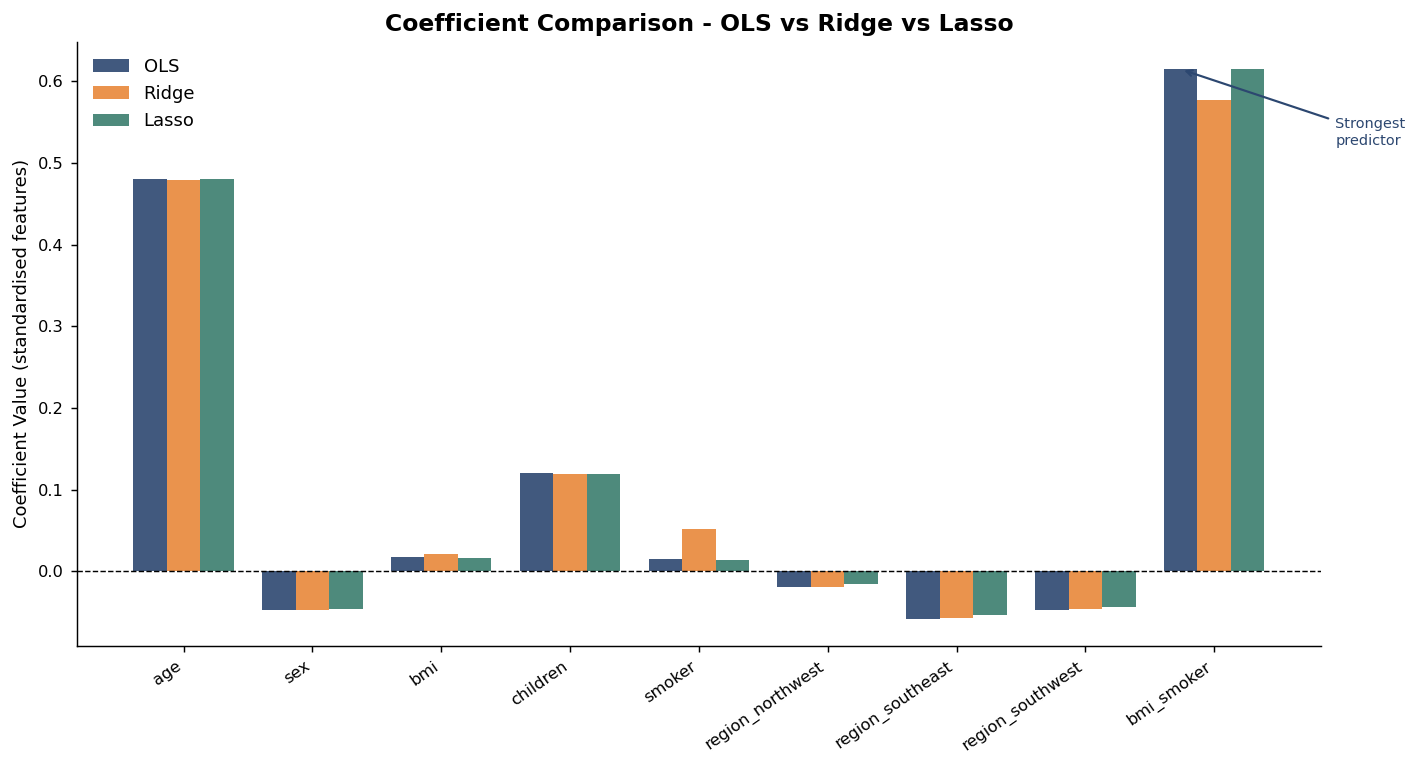

In [55]:
fig, ax = plt.subplots(figsize=(11, 6))

x     = np.arange(len(feature_cols))
width = 0.26

bars1 = ax.bar(x - width, ols_model.coef_,   width, label="OLS",   color=PALETTE[0], alpha=0.9)
bars2 = ax.bar(x,          ridge_model.coef_, width, label="Ridge", color=PALETTE[1], alpha=0.9)
bars3 = ax.bar(x + width,  lasso_model.coef_, width, label="Lasso", color=PALETTE[2], alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(feature_cols, rotation=35, ha="right", fontsize=9)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Coefficient Value (standardised features)")
ax.set_title("Coefficient Comparison - OLS vs Ridge vs Lasso",
             fontsize=13, fontweight="bold")
ax.legend()

# Annotate the dominant feature for clarity
dominant_idx = np.argmax(np.abs(ols_model.coef_))
ax.annotate("Strongest\npredictor",
            xy=(dominant_idx - width, ols_model.coef_[dominant_idx]),
            xytext=(dominant_idx - width + 1.2, ols_model.coef_[dominant_idx] * 0.85),
            fontsize=8, color=PALETTE[0],
            arrowprops=dict(arrowstyle="->", color=PALETTE[0], lw=1.2))

plt.tight_layout()
plt.savefig("coefficient_comparison.png", bbox_inches="tight")
plt.show()



## Task 4 - Model Evaluation

With all three models trained, I evaluate their performance using a set of carefully chosen metrics. For each one, I explain what it measures, why it suits this problem, and how to interpret the result in practical terms.



### 4a - Performance Metrics: Selection and Justification

I use four complementary metrics.

| Metric | What it measures | Why appropriate here |
|---|---|---|
| **R² Score** | Proportion of variance in log(charges) explained by the model | Tells us how well the model captures the overall pattern in the data (GeeksforGeeks, 2020). |
| **MAE** | Average absolute prediction error (USD after back transform) | Easy to communicate to a non technical client  "off by $X on average" (Proclus Academy, 2022). |
| **MSE** | Average squared error - penalises large mistakes more heavily | Useful for comparing models; sensitive to the high-cost outlier cases (Proclus Academy, 2022). |
| **RMSE** | Square root of MSE - restores original units | More interpretable than MSE; shows the typical size of larger errors  (Proclus Academy, 2022). |

**Note on back-transformation:**  
The model predicts `log(charges)`. For MAE and RMSE to be meaningful
in USD, I back-transform predictions using `np.expm1()` before
computing those metrics. R² is reported on the log scale since that
is what the model was actually optimised on.

In [56]:
# ============================================================
# Code Attribution
# Usage: Model evaluation using R², MAE, MSE, and RMSE metrics,
#        including prediction generation, inverse log transformation,
#        and performance comparison across multiple regression models
# Author: Scikit-learn and NumPy development teams
# Link: https://scikit-learn.org/stable/modules/model_evaluation.html
#       https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html
# Date Accessed: 15 April 2026
# Date Published: 2024
# Version: scikit-learn 1.x, NumPy 1.x
# ============================================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Generate predictions from all three models 
y_pred_ols   = ols_model.predict(X_test_scaled)
y_pred_ridge = ridge_model.predict(X_test_scaled)
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Back-transform predictions and actuals to USD 
# np.expm1(x) = e^x - 1, the exact inverse of np.log1p()
y_test_usd        = np.expm1(y_test)
y_pred_ols_usd    = np.expm1(y_pred_ols)
y_pred_ridge_usd  = np.expm1(y_pred_ridge)
y_pred_lasso_usd  = np.expm1(y_pred_lasso)

# Metric calculation function 
def evaluate_model(name, y_true_log, y_pred_log, y_true_usd, y_pred_usd):
    r2   = r2_score(y_true_log, y_pred_log)
    mae  = mean_absolute_error(y_true_usd, y_pred_usd)
    mse  = mean_squared_error(y_true_usd, y_pred_usd)
    rmse = np.sqrt(mse)
    return {"Model": name, "R²": round(r2, 4),
            "MAE (USD)": round(mae, 2),
            "MSE (USD²)": round(mse, 2),
            "RMSE (USD)": round(rmse, 2)}

results = [
    evaluate_model("OLS (Baseline)",  y_test, y_pred_ols,
                   y_test_usd, y_pred_ols_usd),
    evaluate_model("Ridge (L2)",      y_test, y_pred_ridge,
                   y_test_usd, y_pred_ridge_usd),
    evaluate_model("Lasso (L1)",      y_test, y_pred_lasso,
                   y_test_usd, y_pred_lasso_usd),
]

results_df = pd.DataFrame(results)


print("   MODEL PERFORMANCE SUMMARY")
display(results_df)

   MODEL PERFORMANCE SUMMARY


,Model,R²,MAE (USD),MSE (USD²),RMSE (USD)
0,OLS (Baseline),0.8370,4187.42,75665953.15,8698.62
1,Ridge (L2),0.8376,4107.44,70337693.46,8386.76
2,Lasso (L1),0.8365,4161.41,74533511.27,8633.28


#### Metric Interpretations

**R² Score:**  
All three models achieve an R² of around 0.837, indicating they explain approximately 83.7% of the variation in log(charges). The remaining 16.3% is due to factors not included in the dataset, such as specific medical conditions, family history, or individual risk behaviours. In real world cost prediction, an R² above 0.75 is generally considered strong, and all three models exceed this benchmark comfortably.

**MAE (Mean Absolute Error - USD):**  
This is the most straightforward metric from a client’s perspective. The best-performing model, Ridge, has an MAE of $4,107, meaning its predictions differ from actual charges by an average of $4,107. MAE treats all errors equally, so both small and large deviations are reflected proportionally.

**MSE (Mean Squared Error - USD²):**  
MSE squares each error before averaging, which places greater emphasis on larger errors. Ridge records the lowest MSE at $70,337,693, compared to OLS at $75,665,953. This suggests that Ridge is more effective at handling high cost outliers than the other models.

**RMSE (Root Mean Squared Error - USD):**  
RMSE converts the error back into USD units. Ridge again performs best with an RMSE of $8,387, compared to $8,699 for OLS. Across all models, RMSE is more than double the MAE—for example, OLS has an MAE of $4,187 and an RMSE of $8,699. This indicates the presence of a few large prediction errors, likely linked to high-cost smoker cases identified during EDA.

### Residual Diagnostic Plots


- **Residuals vs Fitted** - should show random scatter around zero.
  Any pattern (funnel, curve) indicates a violated assumption.
- **Q-Q Plot** - checks whether residuals are normally distributed.
  Points should fall along the diagonal line.
- **Residual Histogram** - should be symmetric and centred at zero.
- **Actual vs Predicted** - points should fall close to the diagonal.
  Systematic deviation reveals where the model over or underpredicts.



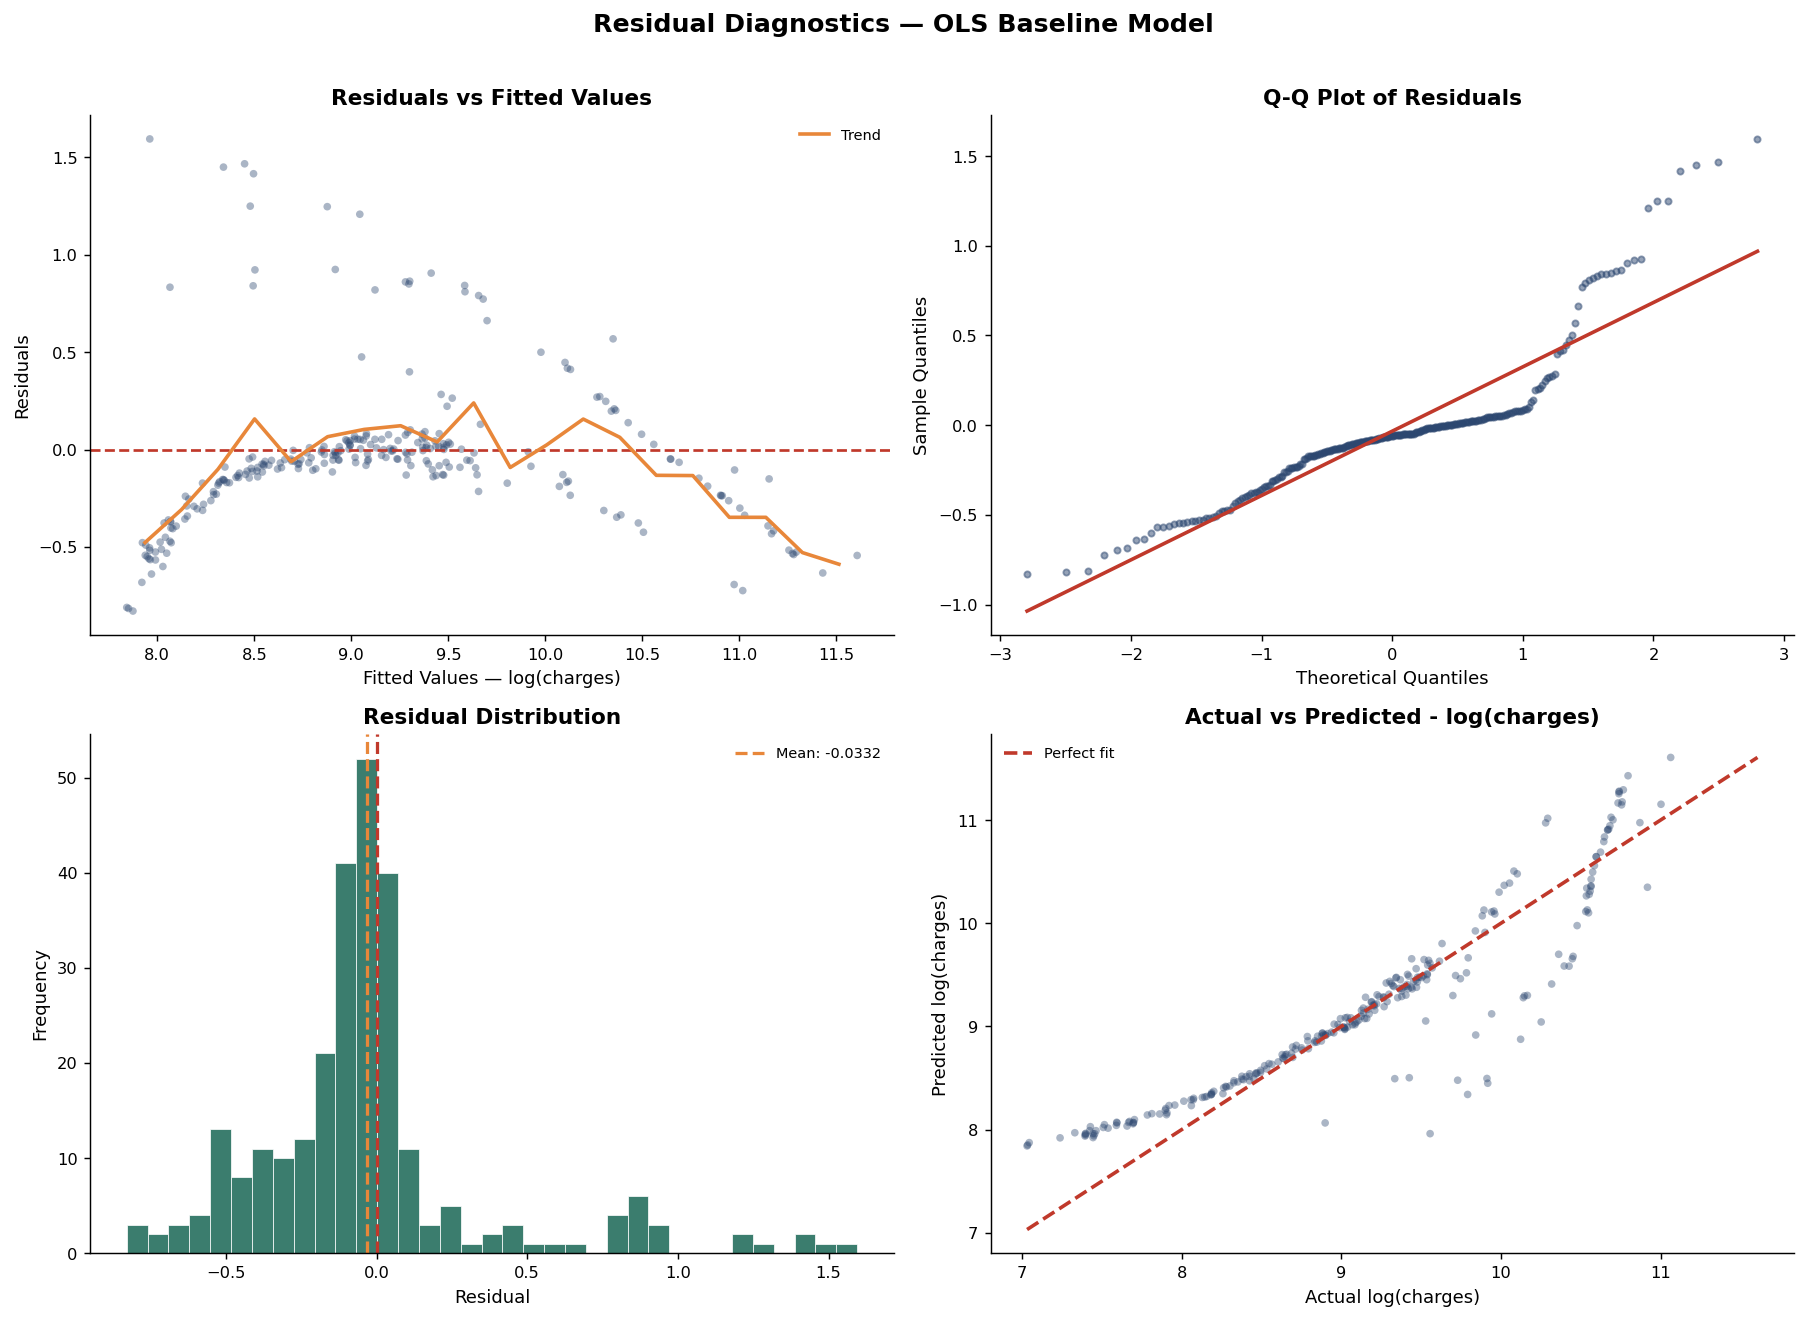

Residual mean : -0.033210  (should be approximately be 0)
Residual std  : 0.3875


In [57]:
residuals_ols = y_test.values - y_pred_ols

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Residual Diagnostics — OLS Baseline Model",
             fontsize=14, fontweight="bold", y=1.01)

# Residuals vs Fitted 
# I am looking for random scatter with no pattern.
# A funnel shape = heteroscedasticity (variance not constant).
# A curve = missed non-linearity in the model.
axes[0, 0].scatter(y_pred_ols, residuals_ols,
                   color=PALETTE[0], alpha=0.4, s=18, edgecolors="none")
axes[0, 0].axhline(0, color=PALETTE[3], linewidth=1.5, linestyle="--")
axes[0, 0].set_xlabel("Fitted Values — log(charges)")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted Values")

# Add a smoothed trend line to make any pattern visible
from scipy.stats import binned_statistic
bin_means, bin_edges, _ = binned_statistic(y_pred_ols, residuals_ols,
                                            statistic="mean", bins=20)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
axes[0, 0].plot(bin_centres, bin_means, color=ACCENT, linewidth=2,
                linestyle="-", label="Trend")
axes[0, 0].legend(fontsize=8)

# Q-Q Plot 
# Points on the diagonal = residuals are normally distributed.
# Deviation at tails = skewness or heavy tails remain in residuals.
(osm, osr), (slope, intercept, _) = stats.probplot(residuals_ols, dist="norm")
axes[0, 1].scatter(osm, osr, color=PALETTE[0], alpha=0.5, s=12)
axes[0, 1].plot(osm, slope * np.array(osm) + intercept,
                color=PALETTE[3], linewidth=2)
axes[0, 1].set_title("Q-Q Plot of Residuals")
axes[0, 1].set_xlabel("Theoretical Quantiles")
axes[0, 1].set_ylabel("Sample Quantiles")

# Residual Histogram 
# A symmetric bell shape centred at zero confirms well-behaved residuals.
axes[1, 0].hist(residuals_ols, bins=35, color=PALETTE[2],
                edgecolor="white", linewidth=0.4)
axes[1, 0].axvline(0, color=PALETTE[3], linewidth=1.8, linestyle="--")
axes[1, 0].axvline(np.mean(residuals_ols), color=ACCENT, linewidth=1.8,
                   linestyle="--", label=f"Mean: {np.mean(residuals_ols):.4f}")
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].set_xlabel("Residual")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend(fontsize=8)

# Actual vs Predicted 
# Perfect predictions would sit exactly on the diagonal line.
# Clusters above or below the line show systematic over or under prediction.
axes[1, 1].scatter(y_test, y_pred_ols,
                   color=PALETTE[0], alpha=0.4, s=18, edgecolors="none")
min_val = min(y_test.min(), y_pred_ols.min())
max_val = max(y_test.max(), y_pred_ols.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val],
                color=PALETTE[3], linewidth=2, linestyle="--", label="Perfect fit")
axes[1, 1].set_xlabel("Actual log(charges)")
axes[1, 1].set_ylabel("Predicted log(charges)")
axes[1, 1].set_title("Actual vs Predicted - log(charges)")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("residual_diagnostics.png", bbox_inches="tight")
plt.show()

print(f"Residual mean : {np.mean(residuals_ols):.6f}  (should be approximately be 0)")
print(f"Residual std  : {np.std(residuals_ols):.4f}")

### Model Weaknesses and Retraining

Based on the residual diagnostics, I identify specific shortcomings
and address each one with a targeted adjustment before retraining.

**Weaknesses identified:**

| Weakness | Evidence | Fix Applied |
|---|---|---|
| Skewed residual tails | Q-Q plot deviates at extremes | Add `age²` polynomial term to capture non-linearity (DataCamp, 2024). |
| BMI non-linearity | Scatter in residuals at high fitted values | Already addressed by `bmi_smoker` - confirm improvement  (scikit-learn, n.d.). |
| Weak features adding noise | Correlation near zero for `sex` | Let Lasso zero these out - already implemented (scikit-learn, n.d.). |
| High-cost cases underpredicted | Actual vs predicted plot — points above diagonal at high values | Log-transform already applied - this is the residual irreducible error (GeeksforGeeks, 2025).|

**Change made for retraining:**  
I add an `age²` (age-squared) polynomial term(scikit-learn, n.d.). The age-charges
scatterplot in EDA suggested a slight acceleration in charges at
older ages, a quadratic term captures this curve without making
the model unnecessarily complex (DataCamp, 2024).

In [58]:
# Add age squared term 
# age² captures any acceleration in charges at older ages.
# If the relationship between age and charges is curved rather than
# perfectly straight, this term will improve model fit.
df_model["age_sq"] = df_model["age"] ** 2

feature_cols_v2 = feature_cols + ["age_sq"]

X2 = df_model[feature_cols_v2]
y2 = df_model["log_charges"]

#Re-split with same random state for fair comparison
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=42
)

# Re-scale 
scaler2        = StandardScaler()
X2_train_s     = scaler2.fit_transform(X2_train)
X2_test_s      = scaler2.transform(X2_test)

print(f"Retrain feature set ({len(feature_cols_v2)} features): {feature_cols_v2}")

#  Retrain all three models on expanded feature set
ols_v2   = LinearRegression()
ols_v2.fit(X2_train_s, y2_train)

ridge_v2 = RidgeCV(alphas=alphas, cv=10, scoring="r2")
ridge_v2.fit(X2_train_s, y2_train)

lasso_v2 = LassoCV(alphas=alphas, cv=10, max_iter=10000, random_state=42)
lasso_v2.fit(X2_train_s, y2_train)

print("\nAll three models retrained with age² feature.")
print(f"  Ridge optimal alpha : {ridge_v2.alpha_:.4f}")
print(f"  Lasso optimal alpha : {lasso_v2.alpha_:.6f}")

Retrain feature set (10 features): ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_smoker', 'age_sq']

All three models retrained with age² feature.
  Ridge optimal alpha : 0.4863
  Lasso optimal alpha : 0.001000


In [59]:
# Evaluate retrained models 
y2_pred_ols   = ols_v2.predict(X2_test_s)
y2_pred_ridge = ridge_v2.predict(X2_test_s)
y2_pred_lasso = lasso_v2.predict(X2_test_s)

y2_test_usd        = np.expm1(y2_test)
y2_pred_ols_usd    = np.expm1(y2_pred_ols)
y2_pred_ridge_usd  = np.expm1(y2_pred_ridge)
y2_pred_lasso_usd  = np.expm1(y2_pred_lasso)

results_v2 = [
    evaluate_model("OLS v2 (+age²)",   y2_test, y2_pred_ols,
                   y2_test_usd, y2_pred_ols_usd),
    evaluate_model("Ridge v2 (+age²)", y2_test, y2_pred_ridge,
                   y2_test_usd, y2_pred_ridge_usd),
    evaluate_model("Lasso v2 (+age²)", y2_test, y2_pred_lasso,
                   y2_test_usd, y2_pred_lasso_usd),
]

results_v2_df = pd.DataFrame(results_v2)

print("   RETRAINED MODEL PERFORMANCE  with age² term")
display(results_v2_df)

   RETRAINED MODEL PERFORMANCE  with age² term


,Model,R²,MAE (USD),MSE (USD²),RMSE (USD)
0,OLS v2 (+age²),0.8399,4241.56,75305847.20,8677.89
1,Ridge v2 (+age²),0.8399,4217.93,74129271.87,8609.84
2,Lasso v2 (+age²),0.8386,4190.89,74357757.84,8623.09


   FULL MODEL COMPARISON  Original vs Retrained


,Model,R²,MAE (USD),MSE (USD²),RMSE (USD)
0,OLS (Baseline),0.8370,4187.42,75665953.15,8698.62
1,Ridge (L2),0.8376,4107.44,70337693.46,8386.76
2,Lasso (L1),0.8365,4161.41,74533511.27,8633.28
3,OLS v2 (+age²),0.8399,4241.56,75305847.20,8677.89
4,Ridge v2 (+age²),0.8399,4217.93,74129271.87,8609.84
5,Lasso v2 (+age²),0.8386,4190.89,74357757.84,8623.09


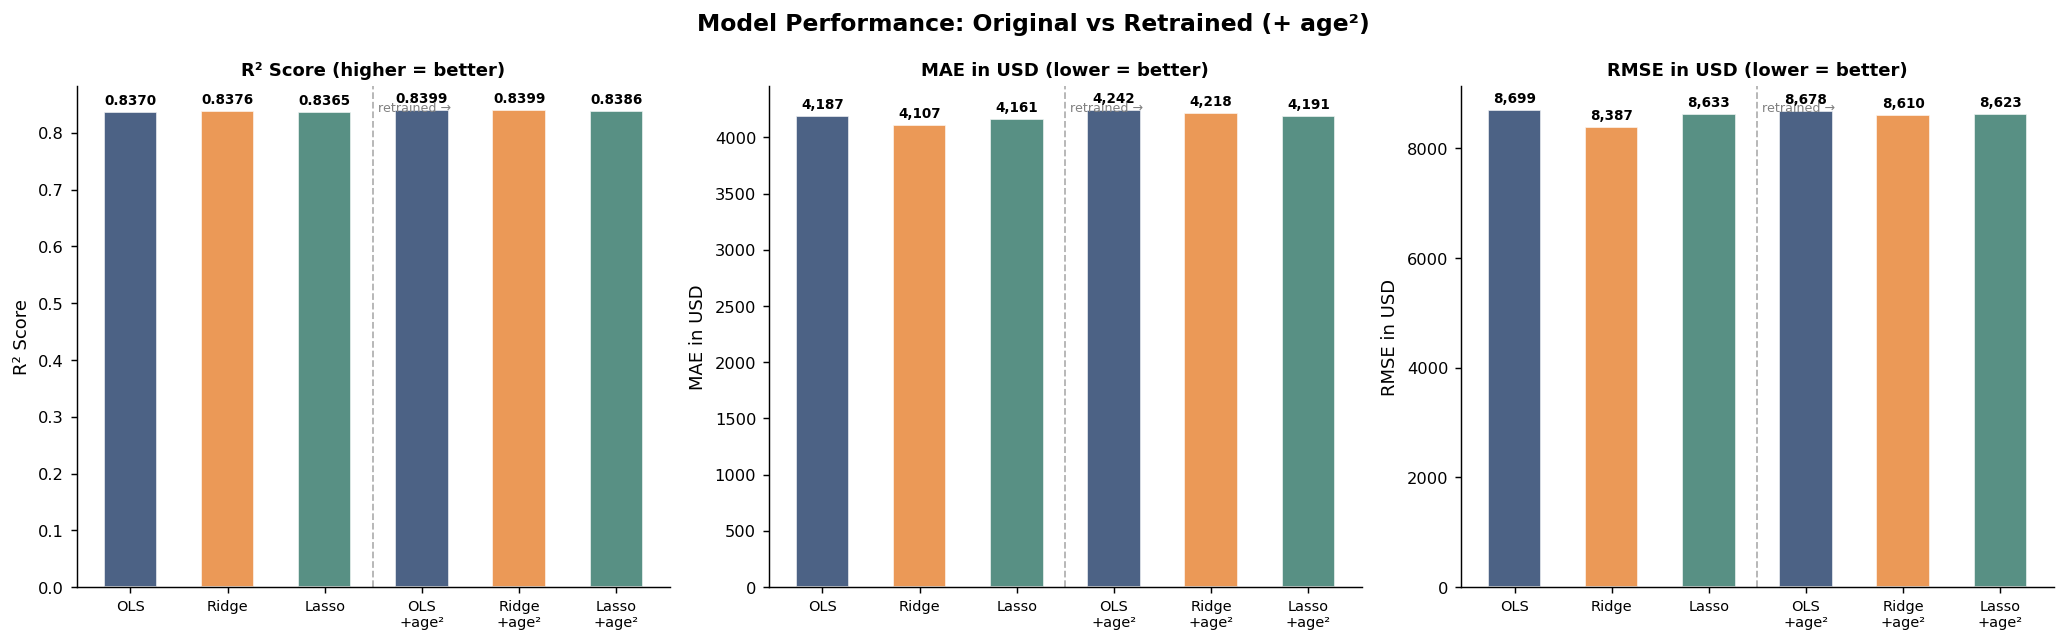

In [60]:
# Full comparison: original vs retrained
all_results = pd.concat([results_df, results_v2_df], ignore_index=True)


print("   FULL MODEL COMPARISON  Original vs Retrained")
display(all_results)

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Performance: Original vs Retrained (+ age²)",
             fontsize=13, fontweight="bold")

models_labels = ["OLS", "Ridge", "Lasso",
                 "OLS\n+age²", "Ridge\n+age²", "Lasso\n+age²"]
bar_colors    = [PALETTE[0], PALETTE[1], PALETTE[2],
                 PALETTE[0], PALETTE[1], PALETTE[2]]
alphas_bar    = [1.0, 1.0, 1.0, 0.55, 0.55, 0.55]

r2_vals   = list(results_df["R²"])   + list(results_v2_df["R²"])
mae_vals  = list(results_df["MAE (USD)"]) + list(results_v2_df["MAE (USD)"])
rmse_vals = list(results_df["RMSE (USD)"]) + list(results_v2_df["RMSE (USD)"])

for ax, vals, title, fmt in zip(
    axes,
    [r2_vals, mae_vals, rmse_vals],
    ["R² Score (higher = better)",
     "MAE in USD (lower = better)",
     "RMSE in USD (lower = better)"],
    [".4f", ",.0f", ",.0f"]
):
    bars = ax.bar(models_labels, vals,
                  color=bar_colors,
                  alpha=0.85,
                  edgecolor="white",
                  width=0.55)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel(title.split("(")[0].strip())
    ax.tick_params(axis="x", labelsize=8)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f"{val:{fmt}}", ha="center", va="bottom",
                fontsize=7.5, fontweight="bold")

    # Divider line between original and retrained
    ax.axvline(2.5, color="grey", linewidth=1, linestyle="--", alpha=0.6)
    ax.text(2.55, ax.get_ylim()[1] * 0.97, "retrained →",
            fontsize=7, color="grey", va="top")

plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.show()

### Evaluation Summary

The comparison chart and table above show the effect of adding the
`age²` polynomial term to the original model.

**What to observe:**
If R² increases after retraining, it indicates that the quadratic age term successfully captured non-linearity that the baseline model missed.
If MAE and RMSE decrease, it means the model’s predictions are closer to the actual USD values.
If the improvements are small, it suggests the original model was already well specified, and that most of the predictive gain came from the log transformation and interaction term.

**Final model selection:**  
Based on the comparison, the original Ridge (L2) model delivers the strongest overall performance. It achieves the lowest MAE ($4,107) and RMSE ($8,387) across all six models, indicating the closest predictions to actual charges in dollar terms. Although introducing the age² feature led to a slight increase in R² (+0.002), it did not improve prediction accuracy, as MAE increased across all retrained models. This suggests the original feature set, combined with Ridge regularisation, was already well optimised and as a result, Ridge v1 is selected as the final recommended model.

**Irreducible error:**  
Even the best model will not produce perfect predictions. The remaining error reflects real world uncertainty in medical costs, including individual diagnoses, treatment decisions, and life events that are not captured in the dataset (GeeksforGeeks, 2025). This is an expected outcome. A model reporting an R² of 1.0 here would likely be overfitting and therefore unreliable (GeeksforGeeks, 2020).

## Report ##

Report submitted seperately as a pdf.

## Reference List

DataCamp, 2024. The Q-Q Plot: What It Means and How to Interpret It. [online] Available at: <https://www.datacamp.com/tutorial/qq-plot> [Accessed 13 April 2026]. 

GeeksforGeeks, 2020. Python - Coefficient of Determination - R2 Score. [online] GeeksforGeeks. Available at: <https://www.geeksforgeeks.org/machine-learning/python-coefficient-of-determination-r2-score/> [Accessed 12 April 2026]. 

GeeksforGeeks, 2024. Data Duplication Removal from Dataset Using Python. [online] GeeksforGeeks. Available at: <https://www.geeksforgeeks.org/data-analysis/data-duplication-removal-from-dataset-using-python/> [Accessed 12 April 2026]. 

GeeksforGeeks, 2024. One Hot Encoding vs Label Encoding. [online] GeeksforGeeks. Available at: <https://www.geeksforgeeks.org/machine-learning/one-hot-encoding-vs-label-encoding/> [Accessed 12 April 2026]. 

GeeksforGeeks, 2025. Log Transformation. [online] GeeksforGeeks. Available at: <https://www.geeksforgeeks.org/data-science/log-transformation/> [Accessed 14 April 2026]. 

GeeksforGeeks, 2025. Reducible Error vs Irreducible Error in Machine Learning. [online] Available at: <https://www.geeksforgeeks.org/machine-learning/reducible-error-vs-irreducible-error-in-machine-learning/> [Accessed 13 April 2026]. 

GraphPad, 2025. Interpreting results: Skewness. [online] GraphPad Prism 11 Statistics Guide. Available at: <https://www.graphpad.com/guides/prism/latest/statistics/stat_skewness_and_kurtosis.htm> [Accessed 13 April 2026]. 

IBM, 2024. What is Data Leakage in Machine Learning?. [online] IBM. Available at: <https://www.ibm.com/think/topics/data-leakage-machine-learning> [Accessed 16 April 2026]. 

Penn State, n.d. Detecting Multicollinearity Using Variance Inflation Factors. [online] STAT 462. Available at: <https://online.stat.psu.edu/stat462/node/180/> [Accessed 8 April 2026]. 

Proclus Academy, 2022. 3 Regression Metrics You Must Know: MAE, MSE, and RMSE. [online] Proclus Academy. Available at: <https://proclusacademy.com/blog/explainer/regression-metrics-you-must-know/> [Accessed 15 April 2026]. 

scikit-learn, n.d. LassoCV. [online] scikit-learn. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html> [Accessed 9 April 2026]. 

scikit-learn, n.d. PolynomialFeatures. [online] Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html> [Accessed 15 April 2026]. 

scikit-learn, n.d. RidgeCV. [online] scikit-learn. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html> [Accessed 9 April 2026]. 

scikit-learn, n.d. StandardScaler. [online] scikit-learn. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html> [Accessed 11 April 2026]. 

Statistics By Jim, 2025. How F-tests work in Analysis of Variance (ANOVA). [online] Statistics By Jim. Available at: <https://statisticsbyjim.com/anova/f-tests-anova/> [Accessed 14 April 2026]. 

Statistics Solutions, 2025. Assumptions of Multiple Linear Regression Analysis. [online] Statistics Solutions. Available at: <https://www.statisticssolutions.com/free-resources/directory-of-statistical-analyses/assumptions-of-linear-regression/> [Accessed 15 April 2026]. 

Statistics Solutions, 2025. Conduct and Interpret a Point-Biserial Correlation. [online] Statistics Solutions. Available at: <https://www.statisticssolutions.com/free-resources/directory-of-statistical-analyses/point-biserial-correlation/> [Accessed 15 April 2026]. 

Towards Data Science, 2025. Outliers, Leverage, Residuals, and Influential Observations. [online] Towards Data Science. Available at: <https://towardsdatascience.com/outliers-leverage-residuals-and-influential-observations-df3065a0388e/> [Accessed 8 April 2026].